# 전기차 배터리 SOC 예측 재검증 (2021 졸업 프로젝트 → 2026)

작성: 이수인 / 기준 자료: 2021 전자공학 졸업 프로젝트(리베니언스팀) 원본 데이터, 코드 캡처, 최종보고서

### 다시 보게 된 계기
- 2021년 졸업 프로젝트에서 무작위 8:2 분할로 R² 0.9999가 나왔고, 당시엔 그 숫자를 그대로 결과로 씀
- SeSAC에서 교차검증, 데이터 누수, 결측 처리를 배우고 나서 회귀 문제에서 0.9999는 너무 높다는 의심이 듦
- 수업 과제와 별개로 원본 xlsx부터 다시 확인해 보기로 함

### 원칙
| 구분 | 내용 | 다루는 방식 |
|---|---|---|
| 2021 졸업 프로젝트 | 원본 xlsx, v4·v6 코드 캡처, `SOC예측코드.ipynb`, 최종보고서 | **수정 안 함.** 원본은 읽기만, 2021 코드는 그대로 재현만 |
| 2026 재검증 | SeSAC 수강 후 진행한 재현, 원인 분석, 재설계 | 수치는 전부 **아래 셀 실행 출력** 기준 |
| 문서 인용 | 논문·보고서·코드 캡처에서 읽은 내용 | 코드 출력이 아니므로 앞에 **[문서 인용]** 표시 |

### 질문과 가설 (돌리기 전에 적어 둔 것)
SeSAC 특강 「분석을 시작할 때부터 설계하는 최종보고서와 발표자료」에서 배운 대로 **가설(검증 전)** 과 **결과(실행 후)** 를 분리해서 기록. 결과는 각 절 출력과 마지막 「결과 요약」 셀에서 확인.

| 번호 | 질문 | 가설 (검증 전) |
|---|---|---|
| Q0 | 2021 데이터는 어디서 왔고 어떤 성격인가 | 논문 그래프를 수치화한 데이터, 실측과 시뮬레이션이 섞여 있을 것 |
| Q1 | 2021 결과(R² 0.9999, 초기 R² 0.7908)는 다시 돌려도 나오나 | 같은 코드면 재현될 것. 다만 난수 미고정이라 MAPE·MPE는 실행마다 다를 것 |
| Q2 | R² 0.9999는 무엇을 측정한 값인가 | 결측을 0으로 채우면서 생긴 규칙적인 패턴을 맞힌 값일 것 |
| Q3 | 시간 순서를 지켜 검증하면 어떻게 달라지나 | 정답 설계가 그대로면 시간순 검증에서도 R²가 높을 수 있음. R²만으로는 판단 불가 |
| Q4 | 문제를 다시 정의하면(계열별·변화율·미래 시점) 어떤 모델이 유효한가 | 데이터가 구간별 직선이라 단순 기울기 연장이 머신러닝과 비슷하거나 더 나을 것 |
| Q5 | 예측 오차는 어디서 생기나 | 예측 구간 안에 기울기 변경점이 있을 때 오차가 몰릴 것 |
| Q6 | 2021 주행거리 환산식은 맞나 | 단위 오류가 있고, 도심·고속 배분식은 환경부 식과 적용 방식이 다를 것 |
| Q7 | 2021년에 안 쓴 데이터(하이브리드, 전압)는 뭐고 쓸 수 있나 | 출처·단위가 달라 바로 결합하기 어려울 것 |

### 실행 방법
1. 저장소 최상위에서 실행 → `data/` 폴더를 자동으로 찾고 결과는 `outputs/`에 저장 (내 PC에서는 2021 원본 폴더를 읽기 전용으로 사용)
2. 필요 패키지: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `openpyxl` (없으면 0장 첫 셀에서 자동 설치)
3. **Kernel → Restart & Run All** 로 처음부터 끝까지 실행
4. 각 절 끝의 `assert`는 원본 파일·2021 캡처와 대조하는 용도. 하나라도 틀리면 거기서 멈춤

## 0. 환경 설정
패키지 확인, 한글 폰트, 난수 고정. 결과 기록용 `RESULTS`와 분석기록표도 여기서 만듦

In [1]:
import importlib
import importlib.util
import shutil
import subprocess
import sys

# 없는 패키지만 설치 (import 이름: pip 이름)
REQUIRED = {"pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "sklearn": "scikit-learn", "openpyxl": "openpyxl"}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]

print("파이썬:", sys.executable)
if missing:
    print("설치할 패키지:", missing)
    # pip → uv → ensurepip 순서로 시도 (uv 가상환경엔 pip가 없음)
    attempts = [
        [sys.executable, "-m", "pip", "install", *missing],
        ["uv", "pip", "install", "--python", sys.executable, *missing],
        [sys.executable, "-m", "ensurepip", "--upgrade"],
        [sys.executable, "-m", "pip", "install", *missing],
    ]
    for cmd in attempts:
        if cmd[0] == "uv" and shutil.which("uv") is None:
            continue                                      # uv 실행 파일이 없으면 건너뜀
        done = subprocess.run(cmd).returncode == 0
        if done and cmd[-len(missing):] == missing:       # 설치되면 중단, ensurepip는 pip만 만든 거라 계속
            break
    importlib.invalidate_caches()                         # 방금 설치한 패키지 바로 import 되게
    still = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
    assert not still, (f"설치 후에도 찾지 못한 패키지: {still}\n"
                       f"터미널에서 다음을 실행한 뒤 커널을 재시작하십시오: uv pip install --python \"{sys.executable}\" {' '.join(still)}")

import hashlib
import json
import platform
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib import font_manager
from sklearn import set_config
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
set_config(display="text")  # Windows cp949 환경에서 Pipeline 출력 시 UnicodeDecodeError 방지 (SeSAC 교재 0장)

# 한글 폰트: 윈도우 맑은 고딕 / 맥 AppleGothic / 그 외 나눔·CJK
font_name = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(platform.system())
if font_name is None:
    font_name = next((f.name for f in font_manager.fontManager.ttflist
                      if "CJK" in f.name or "Nanum" in f.name), "DejaVu Sans")
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지
sns.set_theme(style="whitegrid", font=font_name, rc={"axes.unicode_minus": False})

SEED = 42                    # 난수 기준값
rng = np.random.default_rng(SEED)

RESULTS = {}                 # 절마다 핵심 수치 모아서 마지막에 json 저장
DECISIONS = []               # 분석기록표: 뭘 왜 바꿨는지 기록

print("한글 폰트:", font_name)
for name, ver in [("python", sys.version.split()[0]), ("pandas", pd.__version__), ("numpy", np.__version__),
                  ("scikit-learn", sklearn.__version__), ("matplotlib", matplotlib.__version__), ("seaborn", sns.__version__)]:
    print(f"{name:>12}: {ver}")

파이썬: C:\Users\ergcx\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
한글 폰트: Malgun Gothic
      python: 3.12.10
      pandas: 3.0.5
       numpy: 2.5.2
scikit-learn: 1.9.1
  matplotlib: 3.11.1
     seaborn: 0.13.2


In [2]:
# 데이터 폴더 찾기: 내 PC 경로 → 상위 폴더의 2021 원본 → 노트북 옆 data/
PORTFOLIO = Path.home() / "Documents" / "MalangMalang" / "개인 포트폴리오화"
candidates = [
    PORTFOLIO / "2021 전자공학 졸업논문 증진" / "데이터" / "엑셀화 완료",
    Path.cwd().parent / "2021 전자공학 졸업논문 증진" / "데이터" / "엑셀화 완료",
    Path.cwd() / "data",
]
DATA_DIR = next((p for p in candidates if (p / "데이터.xlsx").exists()), None)
assert DATA_DIR is not None, f"원본 xlsx 폴더를 찾지 못했습니다. 확인한 경로: {[str(p) for p in candidates]}"

# 결과는 outputs/에 저장 (2021 원본 폴더에는 안 씀)
if "2021 전자공학 졸업논문 증진" in DATA_DIR.parts:
    OUT_DIR = DATA_DIR.parents[2] / "SOC_2026_재검증" / "outputs"
else:
    OUT_DIR = Path.cwd() / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
assert "2021 전자공학 졸업논문 증진" not in str(OUT_DIR), "출력 폴더가 2021 원본 폴더 안에 있으면 안 됩니다"

print("원본 데이터(읽기 전용):", DATA_DIR)
print("출력 폴더             :", OUT_DIR)

원본 데이터(읽기 전용): C:\Users\ergcx\Documents\MalangMalang\개인 포트폴리오화\2021 전자공학 졸업논문 증진\데이터\엑셀화 완료
출력 폴더             : C:\Users\ergcx\Documents\MalangMalang\개인 포트폴리오화\SOC_2026_재검증\outputs


## Q0. 데이터 사전 — 파일 목록·중복·출처
분석 전에 파일 단위 정보부터 정리 (SQLD 과정 ERD 용어사전 실습 때 했던 방식)
- MD5 해시가 같으면 이름만 다르고 내용은 같은 파일

In [3]:
inventory = []
for f in sorted(DATA_DIR.glob("*.xlsx")):
    df = pd.read_excel(f)
    inventory.append({"파일": f.name, "MD5(앞 8자리)": hashlib.md5(f.read_bytes()).hexdigest()[:8],
                      "행": df.shape[0], "열": df.shape[1], "컬럼": ", ".join(map(str, df.columns))})
inventory = pd.DataFrame(inventory)

# 같은 해시를 가진 파일끼리 묶어 중복 여부 표시
dup_groups = inventory.groupby("MD5(앞 8자리)")["파일"].agg(list)
inventory["내용이 같은 파일"] = inventory["MD5(앞 8자리)"].map(
    lambda h: " = ".join(dup_groups[h]) if len(dup_groups[h]) > 1 else "")

RESULTS["원본 xlsx 개수"] = len(inventory)
RESULTS["내용이 중복된 파일 쌍"] = int((dup_groups.map(len) > 1).sum())
inventory

,파일,MD5(앞 8자리),행,열,컬럼,내용이 같은 파일
0,bank soc_배터리 수명에 따른.xlsx,f3a99c4d,300,4,"시간(분)/soc, bank1, bank2, bank3",bank soc_배터리 수명에 따른.xlsx = bank_SOC.xlsx
1,bank_SOC.xlsx,f3a99c4d,300,4,"시간(분)/soc, bank1, bank2, bank3",bank soc_배터리 수명에 따른.xlsx = bank_SOC.xlsx
2,soc에따른 주행거리.xlsx,60a5bf4e,100,3,"SOC, 주행거리, 공인전비 383km, 배터리용량 60kwh기준",soc에따른 주행거리.xlsx = 주행거리.xlsx
3,고도_SOC.xlsx,ba8936e9,359,4,"시간(분), 1100고지(100), 성판악(150), 해안도로(70)",
4,데이터.xlsx,01de49c5,241,14,"Unnamed: 0, 시간(분), -20degc, -10degc, 0degc, 10...",
5,배터리 고도-전압fig5.xlsx,0ba33d38,359,4,"시간(분), 1100고지(100), 성판악(150), 해안도로(70)",
6,예측결과.xlsx,a050ac00,100,5,"pred_SOC, test_SOC, 예상주행거리, 실제주행거리, 시간(분)",
7,온도_SOC.xlsx,26b863bf,293,7,"시간(분), -20degc, -10degc, 0degc, 10degc, 25degc...",온도_SOC.xlsx = 온도에 따른 soc_fig4.xlsx
8,온도에 따른 soc_fig4.xlsx,26b863bf,293,7,"시간(분), -20degc, -10degc, 0degc, 10degc, 25degc...",온도_SOC.xlsx = 온도에 따른 soc_fig4.xlsx
9,주행 속도와 soc_하이브리드.xlsx,9a9b613a,60,4,"시간(분)/soc량, 저속주행, 시내 주행, 고속 주행",


**메모** 11개 파일 중 3쌍이 내용 중복
- `bank soc_배터리 수명에 따른.xlsx` = `bank_SOC.xlsx`
- `온도에 따른 soc_fig4.xlsx` = `온도_SOC.xlsx`
- `soc에따른 주행거리.xlsx` = `주행거리.xlsx`

→ 실제로 서로 다른 파일은 8개

**[문서 인용]** 출처표는 `2021 전자공학 졸업논문 증진/데이터`, `관련논문` 폴더의 논문 PDF 본문을 직접 읽고 작성.
핵심은 **생성 방식** 열. 세 데이터는 같은 차량·같은 시점에서 측정한 게 아니고, 그중 하나는 전기차가 아니라 계통연계 ESS 데이터.

In [4]:
SOURCES = pd.DataFrame([
    {"데이터": "고도_SOC.xlsx", "원 출처": "「전기차 주행 데이터에 의한 경로별 배터리 상태 추정」 전력전자학회논문지 24(3), 2019, Fig. 7",
     "생성 방식": "실측 (2017 기아 쏘울 EV, 제주 3개 경로, OBD2로 BMS SOC 취득) → 그래프 수치화", "대상": "전기차(BEV)", "2021 모델 사용": "사용"},
    {"데이터": "온도_SOC.xlsx", "원 출처": "「리튬이온 배터리의 열관리가 전기자동차 주행거리에 미치는 영향」 한국산학기술학회논문지 18(5), 2017, Fig. 4",
     "생성 방식": "시뮬레이션 (AMESim, NEDC 반복 주행) → 그래프 수치화", "대상": "전기차(BEV) 모델", "2021 모델 사용": "사용"},
    {"데이터": "bank_SOC.xlsx", "원 출처": "「전기자동차 배터리 이차적 사용을 위한 SOC 및 C rate 제어 알고리즘」 연세대 학위논문, 표 5.1 조건",
     "생성 방식": "시뮬레이션 (풍력연계 ESS, PSCAD, Long Term profile) → 그래프 수치화", "대상": "계통연계 ESS (Bank 10MWh)", "2021 모델 사용": "사용"},
    {"데이터": "배터리 고도-전압fig5.xlsx", "원 출처": "고도 논문 Fig. 5 (경로별 배터리 전압)",
     "생성 방식": "실측 → 그래프 수치화", "대상": "전기차(BEV)", "2021 모델 사용": "미사용"},
    {"데이터": "주행 속도와 soc_하이브리드.xlsx", "원 출처": "확인 불가 (Q7 참고)",
     "생성 방식": "확인 불가", "대상": "하이브리드(HEV)로 표기", "2021 모델 사용": "미사용"},
    {"데이터": "주행거리.xlsx", "원 출처": "2021 팀 작성 환산표 (셀 메모: 공인전비 383km, 배터리용량 60kWh)",
     "생성 방식": "계산값", "대상": "차종 미기재", "2021 모델 사용": "사용"},
])
SOURCES.to_csv(OUT_DIR / "Q0_데이터_출처표.csv", index=False, encoding="utf-8-sig")
SOURCES

,데이터,원 출처,생성 방식,대상,2021 모델 사용
0,고도_SOC.xlsx,「전기차 주행 데이터에 의한 경로별 배터리 상태 추정」 전력전자학회논문지 24(3)...,"실측 (2017 기아 쏘울 EV, 제주 3개 경로, OBD2로 BMS SOC 취득)...",전기차(BEV),사용
1,온도_SOC.xlsx,「리튬이온 배터리의 열관리가 전기자동차 주행거리에 미치는 영향」 한국산학기술학회논문...,"시뮬레이션 (AMESim, NEDC 반복 주행) → 그래프 수치화",전기차(BEV) 모델,사용
2,bank_SOC.xlsx,「전기자동차 배터리 이차적 사용을 위한 SOC 및 C rate 제어 알고리즘」 연세...,"시뮬레이션 (풍력연계 ESS, PSCAD, Long Term profile) → 그...",계통연계 ESS (Bank 10MWh),사용
3,배터리 고도-전압fig5.xlsx,고도 논문 Fig. 5 (경로별 배터리 전압),실측 → 그래프 수치화,전기차(BEV),미사용
4,주행 속도와 soc_하이브리드.xlsx,확인 불가 (Q7 참고),확인 불가,하이브리드(HEV)로 표기,미사용
5,주행거리.xlsx,"2021 팀 작성 환산표 (셀 메모: 공인전비 383km, 배터리용량 60kWh)",계산값,차종 미기재,사용


## Q0-2. 데이터 점검 — 측정 간격, 결측, 곡선 형태
전처리 실습(260625 Day1) 점검 순서대로: 정보 조회 → 누락 값 → 이상치.
여기에 **기울기 변경점 수**를 추가로 셈.
- 기울기가 계속 일정하다가 몇 군데에서만 바뀐다면 → 센서 측정값이 아니라 그래프의 꺾인 점을 직선으로 이은 수치화 데이터라는 뜻

In [5]:
# 세 원천 데이터를 같은 형태(시간 컬럼명 t)로 불러오기
raw = {
    "온도": pd.read_excel(DATA_DIR / "온도_SOC.xlsx").rename(columns={"시간(분)": "t"}),
    "고도": pd.read_excel(DATA_DIR / "고도_SOC.xlsx").rename(columns={"시간(분)": "t"}),
    "노후도": pd.read_excel(DATA_DIR / "bank_SOC.xlsx").rename(columns={"시간(분)/soc": "t"}),
}

profile = []
for group, df in raw.items():
    for col in df.columns.drop("t"):
        s = df[[ "t", col]].dropna()
        slope = np.diff(s[col].values) / np.diff(s["t"].values)        # 구간별 분당 SOC 변화량
        slope_change = np.abs(np.diff(np.round(slope, 6))) > 1e-6      # 기울기가 바뀐 지점
        profile.append({
            "그룹": group, "계열": col, "관측수": len(s),
            "시간간격(분)": ", ".join(map(str, sorted(set(np.diff(s["t"]).astype(int))))),
            "시작 t": int(s["t"].iloc[0]), "끝 t": int(s["t"].iloc[-1]),
            "시작 SOC": s[col].iloc[0], "끝 SOC": round(s[col].iloc[-1], 4),
            "기울기 변경점 수": int(slope_change.sum()),
            "SOC 증가 구간 수": int((slope > 1e-9).sum()),
        })
profile = pd.DataFrame(profile)
RESULTS["계열 수"] = len(profile)
RESULTS["기울기 변경점 수 최대"] = int(profile["기울기 변경점 수"].max())
RESULTS["고도 데이터의 SOC 증가 구간 수"] = profile.query("그룹 == '고도'").set_index("계열")["SOC 증가 구간 수"].to_dict()
profile.to_csv(OUT_DIR / "Q0_계열별_프로파일.csv", index=False, encoding="utf-8-sig")
profile

,그룹,계열,관측수,시간간격(분),시작 t,끝 t,시작 SOC,끝 SOC,기울기 변경점 수,SOC 증가 구간 수
0,온도,-20degc,185,2,1,369,1.0,0.250,2,0
1,온도,-10degc,229,2,1,457,1.0,0.250,2,0
2,온도,0degc,251,2,1,501,1.0,0.250,4,0
3,온도,10degc,256,2,1,511,1.0,0.250,5,0
4,온도,25degc,293,2,1,585,1.0,0.250,4,0
5,온도,45degc,290,2,1,579,1.0,0.250,4,0
6,고도,1100고지(100),189,1,1,189,0.9,0.105,11,57
7,고도,성판악(150),239,1,1,239,0.9,0.150,18,30
8,고도,해안도로(70),359,1,1,359,0.9,0.150,2,0
9,노후도,bank1,300,1,1,300,0.8,0.380,2,1


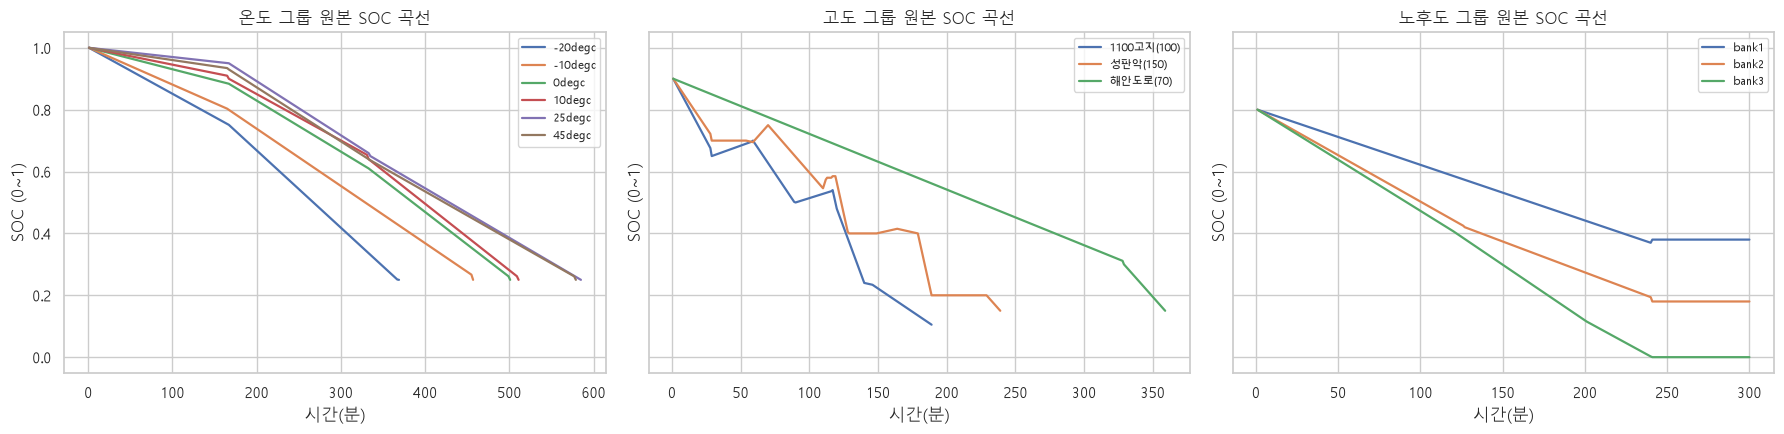

계열 12개, 기울기 변경점 최대 18개
(구간별 직선 여부는 E4에서 확인)

SOC 증가 구간이 있는 계열:
  그룹          계열  SOC 증가 구간 수
 고도 1100고지(100)           57
 고도    성판악(150)           30
노후도       bank1            1


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, (group, df) in zip(axes, raw.items()):
    for col in df.columns.drop("t"):
        ax.plot(df["t"], df[col], label=col, linewidth=1.6)
    ax.set(title=f"{group} 그룹 원본 SOC 곡선", xlabel="시간(분)", ylabel="SOC (0~1)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "Q0_원본_SOC_곡선.png", dpi=150)
plt.show()

print(f"계열 {len(profile)}개, 기울기 변경점 최대 {profile['기울기 변경점 수'].max()}개")
print("(구간별 직선 여부는 E4에서 확인)")
up = profile.query("`SOC 증가 구간 수` > 0")[["그룹", "계열", "SOC 증가 구간 수"]]
print("\nSOC 증가 구간이 있는 계열:\n", up.to_string(index=False))

In [7]:
# SOC가 올라가는 구간(기울기 > 0) 전부 뽑아서 크기 확인
inc_rows = []
for group, df in raw.items():
    for col in df.columns.drop("t"):
        s = df[["t", col]].dropna().reset_index(drop=True)
        dv = np.diff(s[col].to_numpy())
        total_fall = s[col].iloc[0] - s[col].iloc[-1]
        for i in np.where(dv > 1e-9)[0]:
            inc_rows.append({"그룹": group, "계열": col, "구간 시작 t": s["t"][i], "구간 끝 t": s["t"][i + 1],
                             "시작 SOC": s[col][i], "끝 SOC": s[col][i + 1], "증가량": dv[i],
                             "계열 총 하락폭 대비(%)": dv[i] / total_fall * 100})
inc = pd.DataFrame(inc_rows)
inc.to_csv(OUT_DIR / "Q0_SOC_증가구간.csv", index=False, encoding="utf-8-sig")
RESULTS["Q0 SOC 증가 구간 수(계열별)"] = inc.groupby("계열").size().to_dict()
display(inc)

for ser, sub in inc.groupby("계열"):
    print(f"{ser}: 증가 구간 {len(sub)}개, 최대 증가량 {sub['증가량'].max():.4f} (계열 총 하락폭의 {sub['계열 총 하락폭 대비(%)'].max():.1f}%), "
          f"증가 구간 길이 {(sub['구간 끝 t'] - sub['구간 시작 t']).min():g}~{(sub['구간 끝 t'] - sub['구간 시작 t']).max():g}분")
print("\n증가 구간 존재와 크기만 확인. 원인(회생제동 / 수치화 오차)은 이 데이터로 판정 불가")

,그룹,계열,구간 시작 t,구간 끝 t,시작 SOC,끝 SOC,증가량,계열 총 하락폭 대비(%)
0,고도,1100고지(100),29,30,0.6500,0.6516,0.0016,0.201258
1,고도,1100고지(100),30,31,0.6516,0.6532,0.0016,0.201258
2,고도,1100고지(100),31,32,0.6532,0.6548,0.0016,0.201258
3,고도,1100고지(100),32,33,0.6548,0.6564,0.0016,0.201258
4,고도,1100고지(100),33,34,0.6564,0.6580,0.0016,0.201258
...,...,...,...,...,...,...,...,...
83,고도,성판악(150),160,161,0.4110,0.4120,0.0010,0.133333
84,고도,성판악(150),161,162,0.4120,0.4130,0.0010,0.133333
85,고도,성판악(150),162,163,0.4130,0.4140,0.0010,0.133333
86,고도,성판악(150),163,164,0.4140,0.4150,0.0010,0.133333


1100고지(100): 증가 구간 57개, 최대 증가량 0.0036 (계열 총 하락폭의 0.5%), 증가 구간 길이 1~1분
bank1: 증가 구간 1개, 최대 증가량 0.0102 (계열 총 하락폭의 2.4%), 증가 구간 길이 1~1분
성판악(150): 증가 구간 30개, 최대 증가량 0.0140 (계열 총 하락폭의 1.9%), 증가 구간 길이 1~1분

증가 구간 존재와 크기만 확인. 원인(회생제동 / 수치화 오차)은 이 데이터로 판정 불가


**메모** SOC가 올라가는 구간은 1100고지 57개, 성판악 30개, bank1 1개 → 고도 데이터 두 경로에 몰려 있음. 아래 논문 내용과 연결해 봄

**[문서 인용]** 고도 논문 2.3절: 고도차가 큰 경로의 내리막에서 회생제동으로 충전 전류가 측정된다고 기술.
논문 설명이 맞다면 1100고지·성판악 계열의 SOC 증가 구간에는 회생제동 효과가 이미 SOC 값 안에 들어 있는 것.
다만 원인을 확인하는 계산은 하지 않았으므로 **원인 미검증**으로 둠.

## Q0-3. 데이터 사전 — 파일별 구조 (코드로 생성)
`엑셀화 완료` 폴더의 xlsx 전부 대상: 행·열 수, 시간 컬럼 범위·간격, 값 범위, 결측 셀 비율.
출처·성격은 위 출처표(**[문서 인용]**), 이 표는 파일에서 읽은 구조만 정리.

In [8]:
dict_rows = []
for f in sorted(DATA_DIR.glob("*.xlsx")):
    df = pd.read_excel(f)
    tcol = next((c for c in df.columns if "시간" in str(c)), None)          # 이름에 '시간'이 들어간 첫 컬럼
    vals = (df.drop(columns=tcol) if tcol else df).select_dtypes("number")
    vals = vals.drop(columns=[c for c in vals.columns if str(c).startswith("Unnamed")], errors="ignore")
    row = {"파일": f.name, "행": len(df), "열": df.shape[1], "시간 컬럼": tcol or "(없음)",
           "값 컬럼": ", ".join(map(str, vals.columns))}
    if tcol:
        t = df[tcol].dropna().to_numpy()
        row.update({"시간 최소": t.min(), "시간 최대": t.max(),
                    "시간 간격(분, 고유값)": ", ".join(f"{v:g}" for v in sorted(set(np.round(np.diff(t), 6))))})
    row.update({"값 최소": vals.min().min(), "값 최대": vals.max().max(), "결측 셀 비율(%)": vals.isna().to_numpy().mean() * 100})
    dict_rows.append(row)
data_dict = pd.DataFrame(dict_rows)
data_dict.to_csv(OUT_DIR / "Q0_데이터사전.csv", index=False, encoding="utf-8-sig")
RESULTS["Q0 데이터사전 파일 수"] = len(data_dict)
display(data_dict)
over1 = data_dict.loc[data_dict["값 최대"] > 1, "파일"].tolist()
print("값 최대 > 1인 파일(0~1 단위 아님 또는 SOC 외 값):", over1)

,파일,행,열,시간 컬럼,값 컬럼,시간 최소,시간 최대,"시간 간격(분, 고유값)",값 최소,값 최대,결측 셀 비율(%)
0,bank soc_배터리 수명에 따른.xlsx,300,4,시간(분)/soc,"bank1, bank2, bank3",1.0,300.0,1,0.000,0.800000,0.000000
1,bank_SOC.xlsx,300,4,시간(분)/soc,"bank1, bank2, bank3",1.0,300.0,1,0.000,0.800000,0.000000
2,soc에따른 주행거리.xlsx,100,3,(없음),"SOC, 주행거리",NaN,NaN,NaN,1.000,638.333333,0.000000
3,고도_SOC.xlsx,359,4,시간(분),"1100고지(100), 성판악(150), 해안도로(70)",1.0,359.0,1,0.105,0.900000,26.926648
4,데이터.xlsx,241,14,시간(분),"-20degc, -10degc, 0degc, 10degc, 25degc, 45deg...",1.0,241.0,1,0.000,1.000000,26.763485
5,배터리 고도-전압fig5.xlsx,359,4,시간(분),"1100고지(100), 성판악(150), 해안도로(70)",1.0,359.0,1,316.000,391.000000,26.926648
6,예측결과.xlsx,100,5,시간(분),"pred_SOC, test_SOC, 예상주행거리, 실제주행거리",260.0,359.0,1,0.000,280.866667,0.000000
7,온도_SOC.xlsx,293,7,시간(분),"-20degc, -10degc, 0degc, 10degc, 25degc, 45degc",1.0,585.0,2,0.250,1.000000,14.448237
8,온도에 따른 soc_fig4.xlsx,293,7,시간(분),"-20degc, -10degc, 0degc, 10degc, 25degc, 45degc",1.0,585.0,2,0.250,1.000000,14.448237
9,주행 속도와 soc_하이브리드.xlsx,60,4,시간(분)/soc량,"저속주행, 시내 주행, 고속 주행",1.0,60.0,1,68.820,73.000000,0.000000


값 최대 > 1인 파일(0~1 단위 아님 또는 SOC 외 값): ['soc에따른 주행거리.xlsx', '배터리 고도-전압fig5.xlsx', '예측결과.xlsx', '주행 속도와 soc_하이브리드.xlsx', '주행거리.xlsx']


## Q0-4. 탐색적 분석(EDA)
모델링 전에 데이터부터 직접 확인.
각 셀 끝 문장은 계산 결과로 만든 문장 → 결과가 바뀌면 문장도 같이 바뀌게 해 둠 (숫자를 손으로 옮기다 틀리는 것 방지)

### E1. 2021 병합표 재구성과 대조
2021 코드가 만든 `데이터.xlsx`를 원본 3종에서 다시 만들어 값까지 같은지 확인

In [9]:
# 2021 코드가 만든 병합표(데이터.xlsx)를 원본 3종에서 다시 만들어 값까지 같은지 확인
df_time_e = pd.DataFrame(list(range(1, 359)), columns=["시간(분)"])
merged = (df_time_e.merge(raw["온도"].rename(columns={"t": "시간(분)"}), on="시간(분)", how="left")
                   .merge(raw["고도"].rename(columns={"t": "시간(분)"}), on="시간(분)", how="outer")
                   .merge(raw["노후도"].rename(columns={"t": "시간(분)"}), on="시간(분)", how="outer"))[:241]   # 2021 In[76]: [:241]
saved_e = pd.read_excel(DATA_DIR / "데이터.xlsx").drop(columns="Unnamed: 0")
assert list(saved_e.columns) == list(merged.columns)
assert np.allclose(saved_e.to_numpy(float), merged.to_numpy(float), equal_nan=True)
SERIES = sorted(set(merged.columns) - {"시간(분)"})
print("원본 그룹별 (행, 열):", {g: df.shape for g, df in raw.items()})
print("병합표:", merged.shape, "→ 데이터.xlsx와 값까지 동일")
print(f"병합표는 원본 고도 {raw['고도']['t'].max():g}분·노후도 {raw['노후도']['t'].max():g}분·온도 {raw['온도']['t'].max():g}분 중 앞 {len(merged)}행(1~{int(merged['시간(분)'].max())}분)만 사용")
print(f"→ 원본 대비 사용 비율: " + ", ".join(f"{g} {merged['시간(분)'].max() / df['t'].max() * 100:.0f}%" for g, df in raw.items()))
print("계열", len(SERIES), "개:", SERIES)

원본 그룹별 (행, 열): {'온도': (293, 7), '고도': (359, 4), '노후도': (300, 4)}
병합표: (241, 13) → 데이터.xlsx와 값까지 동일
병합표는 원본 고도 359분·노후도 300분·온도 585분 중 앞 241행(1~241분)만 사용
→ 원본 대비 사용 비율: 온도 41%, 고도 67%, 노후도 80%
계열 12 개: ['-10degc', '-20degc', '0degc', '10degc', '1100고지(100)', '25degc', '45degc', 'bank1', 'bank2', 'bank3', '성판악(150)', '해안도로(70)']


**메모** 병합표는 앞 241분만 사용 → 원본 길이 대비 온도 41%, 고도 67%, 노후도 80%만 쓴 셈. 온도 데이터는 절반 이상이 모델에 안 들어갔음

### E2. 계열별 기술통계

In [10]:
rows = []
for group, df in raw.items():
    for col in df.columns.drop("t"):
        s = df[["t", col]].dropna()
        d = s[col].describe()
        rows.append({"그룹": group, "계열": col, "관측수": int(d["count"]), "평균": d["mean"], "표준편차": d["std"],
                     "최소": d["min"], "25%": d["25%"], "중앙값": d["50%"], "75%": d["75%"], "최대": d["max"],
                     "시작 SOC": s[col].iloc[0], "끝 SOC": s[col].iloc[-1],
                     "총 하락폭": s[col].iloc[0] - s[col].iloc[-1],
                     "평균 하락률(분당)": (s[col].iloc[0] - s[col].iloc[-1]) / (s["t"].iloc[-1] - s["t"].iloc[0])})
stats = pd.DataFrame(rows).round(4)
stats.to_csv(OUT_DIR / "E2_계열별_기술통계.csv", index=False, encoding="utf-8-sig")
display(stats)

fast, slow = stats.loc[stats["평균 하락률(분당)"].idxmax()], stats.loc[stats["평균 하락률(분당)"].idxmin()]
print(f"분당 평균 하락률 최대 계열: {fast['계열']} ({fast['평균 하락률(분당)']:.4f}/분), 최소 계열: {slow['계열']} ({slow['평균 하락률(분당)']:.4f}/분)")
for g, sub in stats.groupby("그룹", sort=False):
    print(f"  {g}: 시작 SOC {sub['시작 SOC'].min():g}~{sub['시작 SOC'].max():g}, 끝 SOC {sub['끝 SOC'].min():g}~{sub['끝 SOC'].max():g}, "
          f"하락률 {sub['평균 하락률(분당)'].min():.4f}~{sub['평균 하락률(분당)'].max():.4f}/분")
print("\n하락률 최소~최대 배율:", round(stats["평균 하락률(분당)"].max() / stats["평균 하락률(분당)"].min(), 2), "배")
RESULTS["E2 분당 평균 하락률 최대 계열"] = f"{fast['계열']} ({fast['평균 하락률(분당)']:.4f})"
RESULTS["E2 분당 평균 하락률 최소 계열"] = f"{slow['계열']} ({slow['평균 하락률(분당)']:.4f})"

,그룹,계열,관측수,평균,표준편차,최소,25%,중앙값,75%,최대,시작 SOC,끝 SOC,총 하락폭,평균 하락률(분당)
0,온도,-20degc,185,0.6683,0.2235,0.2500,0.4760,0.7060,0.8620,1.0,1.0,0.250,0.750,0.0020
1,온도,-10degc,229,0.6654,0.2206,0.2500,0.4739,0.6848,0.8632,1.0,1.0,0.250,0.750,0.0016
2,온도,0degc,251,0.7060,0.2247,0.2500,0.5197,0.7452,0.9125,1.0,1.0,0.250,0.750,0.0015
3,온도,10degc,256,0.7192,0.2266,0.2500,0.5314,0.7665,0.9299,1.0,1.0,0.250,0.750,0.0015
4,온도,25degc,293,0.7005,0.2443,0.2500,0.4836,0.7295,0.9562,1.0,1.0,0.250,0.750,0.0013
5,온도,45degc,290,0.6938,0.2390,0.2500,0.4822,0.7147,0.9422,1.0,1.0,0.250,0.750,0.0013
6,고도,1100고지(100),189,0.4902,0.2249,0.1050,0.2380,0.5252,0.6736,0.9,0.9,0.105,0.795,0.0042
7,고도,성판악(150),239,0.5063,0.2174,0.1500,0.3900,0.5460,0.7000,0.9,0.9,0.150,0.750,0.0032
8,고도,해안도로(70),359,0.5728,0.1956,0.1500,0.4167,0.5778,0.7389,0.9,0.9,0.150,0.750,0.0021
9,노후도,bank1,300,0.5439,0.1386,0.3698,0.3964,0.5309,0.6654,0.8,0.8,0.380,0.420,0.0014


분당 평균 하락률 최대 계열: 1100고지(100) (0.0042/분), 최소 계열: 25degc (0.0013/분)
  온도: 시작 SOC 1~1, 끝 SOC 0.25~0.25, 하락률 0.0013~0.0020/분
  고도: 시작 SOC 0.9~0.9, 끝 SOC 0.105~0.15, 하락률 0.0021~0.0042/분
  노후도: 시작 SOC 0.8~0.8, 끝 SOC 0~0.38, 하락률 0.0014~0.0027/분

하락률 최소~최대 배율: 3.23 배


### E3. SOC 값의 분포(그룹별)

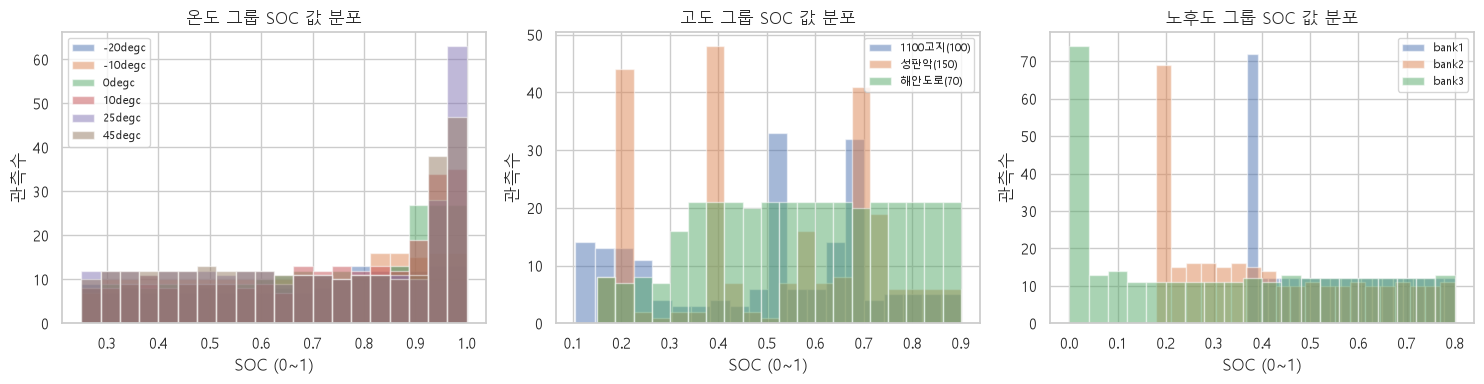

온도: 관측 1504개, SOC 0.25~1, 최다 구간 [0.963, 1.000) 에 13.4%
고도: 관측 787개, SOC 0.105~0.9, 최다 구간 [0.661, 0.701) 에 11.9%
노후도: 관측 900개, SOC 0~0.8, 최다 구간 [0.360, 0.400) 에 12.1%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (group, df) in zip(axes, raw.items()):
    for col in df.columns.drop("t"):
        ax.hist(df[col].dropna(), bins=20, alpha=0.5, label=col)
    ax.set(title=f"{group} 그룹 SOC 값 분포", xlabel="SOC (0~1)", ylabel="관측수")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "E3_SOC_분포.png", dpi=150); plt.show()

# 그룹별로 관측이 가장 많이 몰린 SOC 구간(20개 구간 기준)과 그 비율
for group, df in raw.items():
    v = df.drop(columns="t").to_numpy().ravel()
    v = v[~np.isnan(v)]
    cnt, edges = np.histogram(v, bins=20)
    k = cnt.argmax()
    print(f"{group}: 관측 {len(v)}개, SOC {v.min():g}~{v.max():g}, 최다 구간 [{edges[k]:.3f}, {edges[k + 1]:.3f}) 에 {cnt[k] / len(v) * 100:.1f}%")

### E4. 구간별 분당 기울기 — 기울기가 바뀌는 지점

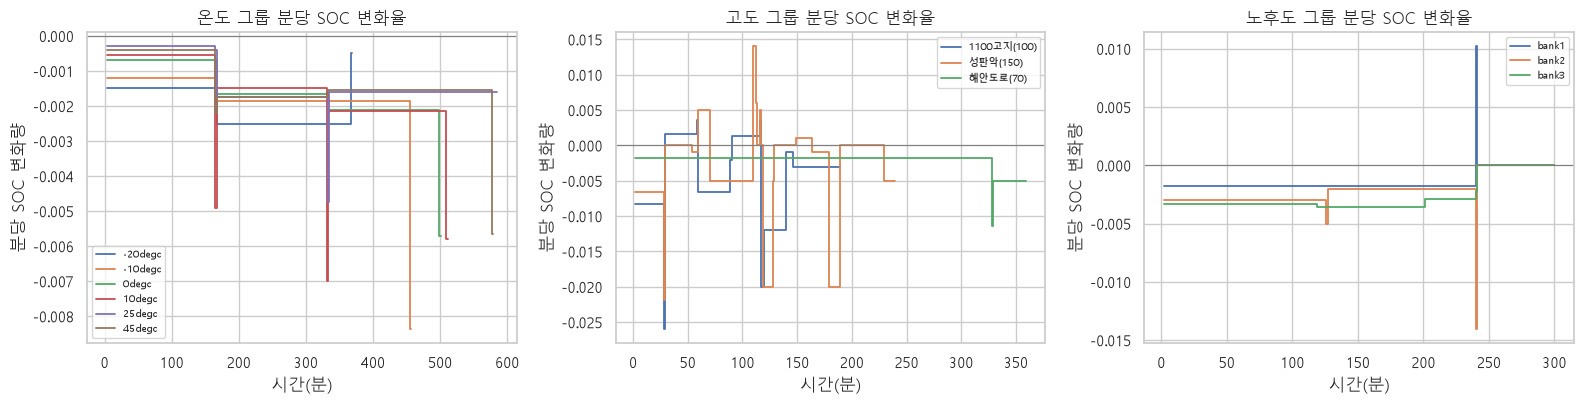

,계열,구간 수,기울기 변경점 수,직전과 같은 기울기 구간 비율(%)
0,-20degc,184,2,98.91
1,-10degc,228,2,99.12
2,0degc,250,4,98.39
3,10degc,255,5,98.03
4,25degc,292,4,98.63
5,45degc,289,4,98.61
6,1100고지(100),188,11,94.12
7,성판악(150),238,18,92.41
8,해안도로(70),358,2,99.44
9,bank1,299,2,99.33


계열 12개 모두 직전과 같은 기울기 구간 비율 92.4% 이상
기울기 변경점: 계열당 최소 2개, 최대 18개


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
seg_rows = []
for ax, (group, df) in zip(axes, raw.items()):
    for col in df.columns.drop("t"):
        s = df[["t", col]].dropna()
        slope = np.diff(s[col].to_numpy()) / np.diff(s["t"].to_numpy())      # 구간별 분당 SOC 변화량
        ax.step(s["t"].to_numpy()[1:], slope, where="pre", label=col, linewidth=1.3)
        n_change = int((np.abs(np.diff(np.round(slope, 6))) > 1e-6).sum())
        seg_rows.append({"계열": col, "구간 수": len(slope), "기울기 변경점 수": n_change,
                         "직전과 같은 기울기 구간 비율(%)": (1 - n_change / (len(slope) - 1)) * 100})
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set(title=f"{group} 그룹 분당 SOC 변화율", xlabel="시간(분)", ylabel="분당 SOC 변화량")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT_DIR / "E4_구간별_기울기.png", dpi=150); plt.show()

seg = pd.DataFrame(seg_rows).round(2)
seg.to_csv(OUT_DIR / "E4_기울기_변경점.csv", index=False, encoding="utf-8-sig")
display(seg)
print(f"계열 {len(seg)}개 모두 직전과 같은 기울기 구간 비율 {seg['직전과 같은 기울기 구간 비율(%)'].min():.1f}% 이상")
print(f"기울기 변경점: 계열당 최소 {seg['기울기 변경점 수'].min()}개, 최대 {seg['기울기 변경점 수'].max()}개")
RESULTS["E4 직전과 같은 기울기 구간 비율 최소(%)"] = float(seg["직전과 같은 기울기 구간 비율(%)"].min())

**메모** 직전과 같은 기울기 구간 비율이 가장 낮은 계열도 92.4%(성판악), 대부분 98% 이상 → 사실상 직선 몇 개를 이어 붙인 데이터. Q4·Q5 설계의 출발점

### E5. 결측 패턴 지도 (병합표 241행 × 12계열)

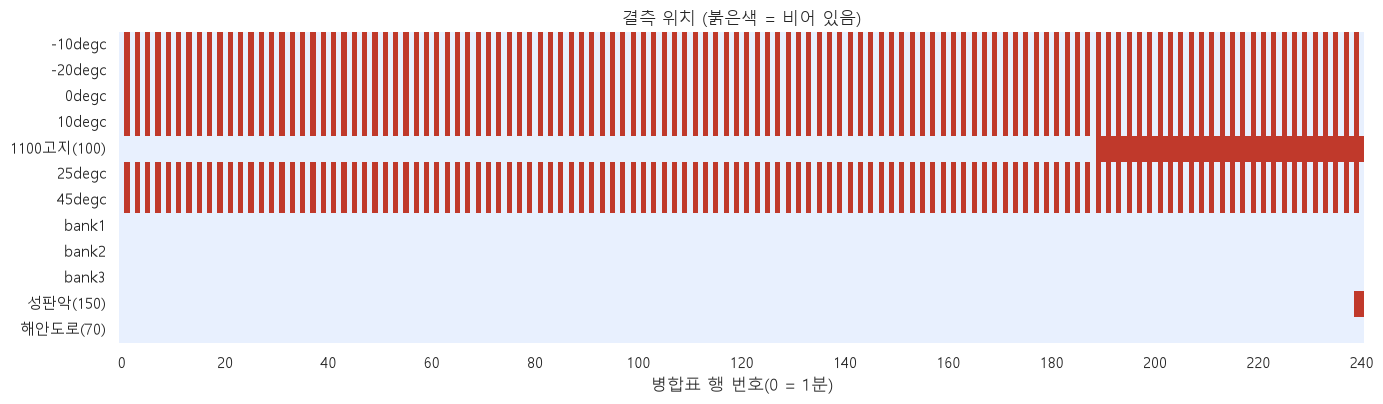

계열별 결측 비율(%):
-10degc        49.8
-20degc        49.8
0degc          49.8
10degc         49.8
1100고지(100)    21.6
25degc         49.8
45degc         49.8
bank1           0.0
bank2           0.0
bank3           0.0
성판악(150)        0.8
해안도로(70)        0.0

온도 계열의 결측 행 시간(분) % 2 값: {'-10degc': [0], '-20degc': [0], '0degc': [0], '10degc': [0], '25degc': [0], '45degc': [0]} (0 = 짝수 분)
온도 6개 계열 결측이 전부 짝수 분인가: True
12개 계열이 모두 관측된 행: 95행 / 241행


In [13]:
miss = merged[SERIES].isna().T
fig, ax = plt.subplots(figsize=(14, 4.2))
sns.heatmap(miss, cmap=["#e8f0fe", "#c0392b"], cbar=False, ax=ax, xticklabels=20)
ax.set(title="결측 위치 (붉은색 = 비어 있음)", xlabel="병합표 행 번호(0 = 1분)", ylabel="")
plt.tight_layout(); plt.savefig(OUT_DIR / "E5_결측_지도.png", dpi=150); plt.show()

miss_rate = (merged[SERIES].isna().mean() * 100).round(1)
print("계열별 결측 비율(%):")
print(miss_rate.to_string())
temp_cols = [c for c in SERIES if c.endswith("degc")]
parity = {c: sorted(set((merged.loc[merged[c].isna(), "시간(분)"] % 2).astype(int))) for c in temp_cols}
print("\n온도 계열의 결측 행 시간(분) % 2 값:", parity, "(0 = 짝수 분)")
print("온도 6개 계열 결측이 전부 짝수 분인가:", all(v == [0] for v in parity.values()))
rows_all_obs = merged[SERIES].notna().all(axis=1)
print(f"12개 계열이 모두 관측된 행: {int(rows_all_obs.sum())}행 / {len(merged)}행")
RESULTS["E5 온도 결측이 짝수 분에만 있는가"] = bool(all(v == [0] for v in parity.values()))
RESULTS["E5 12계열 모두 관측된 행 수"] = int(rows_all_obs.sum())

**메모** 온도 6개 계열은 짝수 분에서만 비어 있음 (2분 간격 측정). 12개 계열이 모두 관측된 행은 241행 중 95행뿐.
2021 코드는 이 결측을 0으로 채움 → 0과 실제 값이 한 행씩 번갈아 나오는 규칙이 생겼을 수 있음. Q2에서 확인

### E6. 계열 간 상관 — 해석 주의

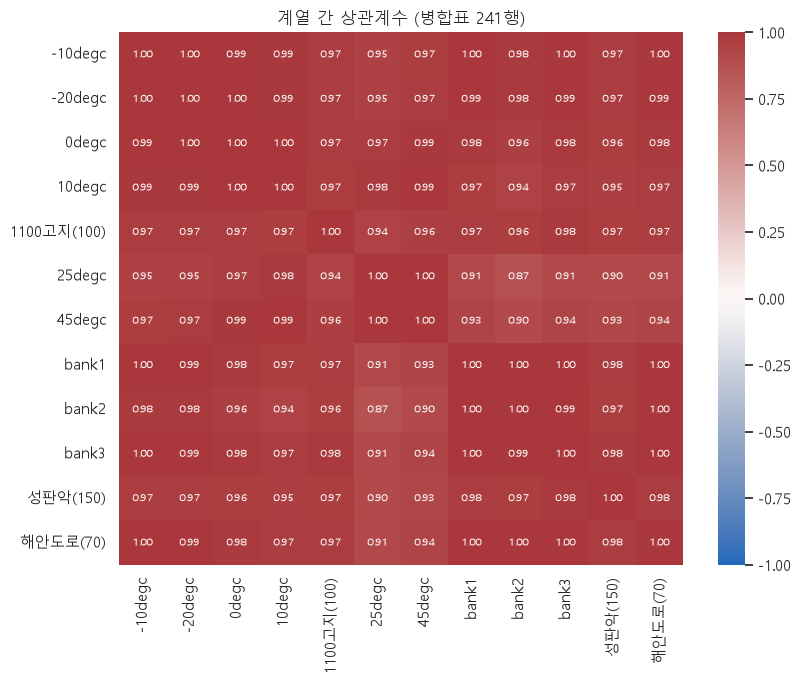

계열 쌍 66개, 상관 0 이하인 쌍 0개, 상관계수 최소 0.871 ~ 최대 1.000
변화량(1행 차분) 상관: 최소 -0.816 ~ 최대 0.344
→ 수준 상관 vs 변화량 상관 비교 = 공통 시간 추세 영향 확인용


In [14]:
corr = merged[SERIES].corr()                                            # 쌍별 완전 관측 행만 사용
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, annot_kws={"size": 7}, ax=ax)
ax.set(title="계열 간 상관계수 (병합표 241행)")
plt.tight_layout(); plt.savefig(OUT_DIR / "E6_계열간_상관.png", dpi=150); plt.show()

off = corr.where(~np.eye(len(corr), dtype=bool))
n_pairs = len(corr) * (len(corr) - 1) // 2
n_nonpos = int((corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)) <= 0).sum().sum())
print(f"계열 쌍 {n_pairs}개, 상관 0 이하인 쌍 {n_nonpos}개, 상관계수 최소 {off.min().min():.3f} ~ 최대 {off.max().max():.3f}")

# 상관이 시간 추세 때문인지 보려고 변화량끼리도 상관 계산
diff_corr = merged[SERIES].diff().corr()
off_d = diff_corr.where(~np.eye(len(diff_corr), dtype=bool))
print(f"변화량(1행 차분) 상관: 최소 {off_d.min().min():.3f} ~ 최대 {off_d.max().max():.3f}")
print("→ 수준 상관 vs 변화량 상관 비교 = 공통 시간 추세 영향 확인용")
RESULTS["E6 수준 상관 최소·최대"] = [round(float(off.min().min()), 3), round(float(off.max().max()), 3)]
RESULTS["E6 차분 상관 최소·최대"] = [round(float(off_d.min().min()), 3), round(float(off_d.max().max()), 3)]

**메모** SOC 값끼리 상관은 0.871~1.000으로 전부 높지만 변화량끼리 상관은 -0.816~0.344. 모두 시간이 지나며 줄어드는 값이라 생긴 상관 → 계열 간 관계의 근거로 쓰면 안 됨

### E7. 시간에 대한 직선 적합 — 얼마나 직선에 가까운가

In [15]:
rows = []
for group, df in raw.items():
    for col in df.columns.drop("t"):
        s = df[["t", col]].dropna()
        slope, intercept = np.polyfit(s["t"], s[col], 1)
        pred = slope * s["t"] + intercept
        r2 = 1 - ((s[col] - pred) ** 2).sum() / ((s[col] - s[col].mean()) ** 2).sum()
        rows.append({"그룹": group, "계열": col, "직선 기울기(분당)": slope, "절편": intercept, "직선 적합 R²": r2})
lin = pd.DataFrame(rows).round(4)
lin.to_csv(OUT_DIR / "E7_직선적합.csv", index=False, encoding="utf-8-sig")
display(lin)
lo, hi = lin.loc[lin["직선 적합 R²"].idxmin()], lin.loc[lin["직선 적합 R²"].idxmax()]
print(f"직선 적합 R² 최소 {lo['직선 적합 R²']:.4f} ({lo['계열']}), 최대 {hi['직선 적합 R²']:.4f} ({hi['계열']})")
print("곡선 모양 요약값일 뿐 모델 성능 아님. 이후 모델은 '직선에서 벗어나는 부분'을 얼마나 맞히는지로 비교")
RESULTS["E7 직선 적합 R² 최소·최대"] = [round(float(lo["직선 적합 R²"]), 4), round(float(hi["직선 적합 R²"]), 4)]

,그룹,계열,직선 기울기(분당),절편,직선 적합 R²
0,온도,-20degc,-0.0021,1.0517,0.9861
1,온도,-10degc,-0.0017,1.0452,0.9925
2,온도,0degc,-0.0015,1.0884,0.9688
3,온도,10degc,-0.0015,1.1026,0.9580
4,온도,25degc,-0.0014,1.1167,0.9709
5,온도,45degc,-0.0014,1.1023,0.9774
6,고도,1100고지(100),-0.0040,0.8707,0.9491
7,고도,성판악(150),-0.0031,0.8745,0.9515
8,고도,해안도로(70),-0.0019,0.9109,0.9930
9,노후도,bank1,-0.0016,0.7813,0.9739


직선 적합 R² 최소 0.9491 (1100고지(100)), 최대 0.9930 (해안도로(70))
곡선 모양 요약값일 뿐 모델 성능 아님. 이후 모델은 '직선에서 벗어나는 부분'을 얼마나 맞히는지로 비교


**메모** 시간 하나로 직선 적합만 해도 R² 0.949~0.993 → 이 데이터는 R²가 높게 나오기 쉬운 구조라는 걸 먼저 염두에 둠

## Q1. 2021 결과 재현
2021 v6 코드 캡처(`v6코드pdf.pdf`, In[75]~[81])와 v4 코드 캡처(`v4_SOC_코드캡쳐.pdf`)를 로직 그대로 옮김. 바꾼 건 두 가지뿐.

| 2021 코드 | 여기서 | 이유 |
|---|---|---|
| `list(set(...))` → 실행마다 컬럼 순서가 달라짐 | `sorted(...)`로 고정 | 재현성. 12개 예측값의 **평균**을 쓰므로 순서와 상관없이 같은 값이 나오는지 아래 셀에서 확인 |
| `RandomForestRegressor()` 난수 미고정 | `random_state=seed`로 여러 번 반복 | 2021 수치가 실행마다 달랐던 이유 확인용 |

2021 코드의 `lst_X = list(set(lst_cols) - set(label_col))`가 실제로 뭘 빼는지는 병합 직후 셀에서 직접 계산해 봄.

In [16]:
# ── 2021 v6 In[74]~[76]과 동일한 병합 ──
df_dc = pd.read_excel(DATA_DIR / "온도_SOC.xlsx")
df_ht = pd.read_excel(DATA_DIR / "고도_SOC.xlsx")
df_bk = pd.read_excel(DATA_DIR / "bank_SOC.xlsx").rename(columns={"시간(분)/soc": "시간(분)"})

df_time = pd.DataFrame(list(range(1, 359)), columns=["시간(분)"])
df_total_full = (df_time.merge(df_dc, on="시간(분)", how="left")
                        .merge(df_ht, on="시간(분)", how="outer")
                        .merge(df_bk, on="시간(분)", how="outer"))
df_total = df_total_full[:241]                                   # 2021 In[76]: df_total[:241]

# 검증: 2021 코드가 저장한 데이터.xlsx와 값까지 완전히 같은지
saved = pd.read_excel(DATA_DIR / "데이터.xlsx").drop(columns="Unnamed: 0")
assert list(saved.columns) == list(df_total.columns)
assert np.allclose(saved.to_numpy(float), df_total.to_numpy(float), equal_nan=True)

LST_COLS = sorted(set(df_total.columns) - {"시간(분)"})
print(f"병합 결과 {df_total.shape} — 데이터.xlsx와 동일")
print(f"예측 대상 계열 {len(LST_COLS)}개:", LST_COLS)
print("\n컬럼별 결측 비율(%):")
print((df_total[LST_COLS].isna().mean() * 100).round(1).to_string())

병합 결과 (241, 13) — 데이터.xlsx와 동일
예측 대상 계열 12개: ['-10degc', '-20degc', '0degc', '10degc', '1100고지(100)', '25degc', '45degc', 'bank1', 'bank2', 'bank3', '성판악(150)', '해안도로(70)']

컬럼별 결측 비율(%):
-10degc        49.8
-20degc        49.8
0degc          49.8
10degc         49.8
1100고지(100)    21.6
25degc         49.8
45degc         49.8
bank1           0.0
bank2           0.0
bank3           0.0
성판악(150)        0.8
해안도로(70)        0.0


In [17]:
# 2021 코드의 lst_X = list(set(lst_cols) - set(label_col)) 가 실제로 무엇을 빼는지 직접 계산
removed_counts = {}
for label_col in [c + "_label" for c in LST_COLS]:
    lst_X = list(set(LST_COLS) - set(label_col))              # set(label_col): 문자열의 '글자 집합'
    removed_counts[label_col] = len(LST_COLS) - len(lst_X)
example = "25degc_label"
print(f"예) set('{example}') = {sorted(set(example))}")
print("lst_X가 빼는 컬럼 수(라벨 12개 기준):", sorted(set(removed_counts.values())), "(0 = 안 뺌)")
print("입력에 '_label'(미래 값) 포함 여부:", any(c.endswith("_label") for c in LST_COLS))
print("입력 컬럼 수:", len(LST_COLS), "→ 12개 계열 현재 값")

# 컬럼 순서를 바꿔도 12개 예측값의 평균(정답)이 같은지 확인
lab_all = df_total[LST_COLS].shift(-1).fillna(0)
shuffled = list(np.random.default_rng(0).permutation(LST_COLS))
print("컬럼 순서 섞어도 평균 정답 동일:", bool(np.allclose(lab_all.mean(axis=1), lab_all[shuffled].mean(axis=1))))
RESULTS["Q1 set(label_col)이 빼는 컬럼 수"] = sorted(set(removed_counts.values()))

예) set('25degc_label') = ['2', '5', '_', 'a', 'b', 'c', 'd', 'e', 'g', 'l']
lst_X가 빼는 컬럼 수(라벨 12개 기준): [0] (0 = 안 뺌)
입력에 '_label'(미래 값) 포함 여부: False
입력 컬럼 수: 12 → 12개 계열 현재 값
컬럼 순서 섞어도 평균 정답 동일: True


**코드 리뷰 메모** `set(label_col)`은 컬럼 이름이 아니라 문자열의 **글자 집합**('2', '5', '_', 'a', …)이 됨 → `lst_X`에서 빠지는 컬럼 0개. 라벨 컬럼을 빼려던 2021 코드의 의도대로 동작하지 않았던 것.
다행히 입력에 `_label`(미래 값) 컬럼은 애초에 없어서 이 부분 때문에 생긴 누수는 없음.

In [18]:
# 2021 지표 6종, 정의 그대로 (y=0이면 MAPE inf 나는 것까지 그대로 둠)
def metrics_2021(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_true - y_pred
    with np.errstate(divide="ignore", invalid="ignore"):
        return {"R2": r2_score(y_true, y_pred), "MAE": np.mean(np.abs(err)), "MSE": np.mean(err ** 2),
                "RMSE": np.sqrt(np.mean(err ** 2)),
                "MAPE": np.mean(np.abs(err / y_true)) * 100, "MPE": np.mean(err / y_true) * 100}


# 2021 v6(무작위 8:2) / v4(마지막 100행) 반복문을 그대로 옮긴 함수
def run_2021(df_total, split, seed):
    lst_pred, lst_test = [], []
    df_label = df_total[LST_COLS].shift(-1)                          # 다음 시점 값을 정답으로
    df_label.columns = [c + "_label" for c in df_label.columns]
    df_xy = pd.concat([df_total, df_label], axis=1)
    for label_col in [c + "_label" for c in LST_COLS]:
        X, y = df_xy.drop([label_col], axis=1), df_xy[label_col].fillna(0)   # 2021: 정답 결측을 0으로
        if split == "random":
            X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        else:
            X_train, X_test, Y_train, Y_test = X.iloc[:-100], X.iloc[-100:], y.iloc[:-100], y.iloc[-100:]
        test_time = X_test["시간(분)"].to_numpy()
        X_train, X_test = X_train[LST_COLS].fillna(0), X_test[LST_COLS].fillna(0)  # 2021: 입력 결측도 0으로
        grid = GridSearchCV(RandomForestRegressor(random_state=seed),
                            {"bootstrap": [False], "n_estimators": [3, 5, 7, 9], "max_features": [2, 4, 6, 8]},
                            cv=3, n_jobs=-1, scoring="neg_mean_squared_error").fit(X_train, Y_train)
        lst_pred.append(grid.best_estimator_.predict(X_test))
        lst_test.append(Y_test.to_numpy())
    y_pred, y_true = np.mean(lst_pred, axis=0), np.mean(lst_test, axis=0)   # 2021: 12개 계열 평균
    return {"y_true": y_true, "y_pred": y_pred, "time": test_time}


SEEDS = range(10)
runs = {(split, s): run_2021(df_total, split, s) for split in ["random", "last100"] for s in SEEDS}
rep = pd.DataFrame([{"분할": split, "seed": s, **metrics_2021(r["y_true"], r["y_pred"])}
                    for (split, s), r in runs.items()])
rep_summary = rep.groupby("분할")[["R2", "MAE", "RMSE", "MAPE", "MPE"]].agg(["min", "max"]).round(4)
rep_summary

R2             MAE            RMSE            MAPE         \
            min     max     min     max     min     max     min    max   
분할                                                                       
last100  0.7903  0.7915  0.0803  0.0810  0.0974  0.0977     inf    inf   
random   0.9997  0.9999  0.0016  0.0022  0.0019  0.0046  0.4065  1.072   

            MPE          
            min     max  
분할                       
last100    -inf    -inf  
random   0.1203  0.8965

In [19]:
# 2021 문서에 적힌 값 (출처: 최종보고서 9항 캡처, v6 캡처 In[79], v4 캡처 In[29])
REPORTED_2021 = pd.DataFrame([
    {"출처": "최종보고서 (무작위 8:2)", "분할": "random",  "R2": 0.9999, "MAPE": 0.50, "MPE": 0.31},
    {"출처": "v6 코드 캡처 (무작위 8:2)", "분할": "random",  "R2": 0.9999, "MAPE": 0.71, "MPE": 0.08},
    {"출처": "v4 코드 캡처 (마지막 100행)", "분할": "last100", "R2": 0.7908, "MAPE": np.inf, "MPE": -np.inf},
])

check = []
for _, row in REPORTED_2021.iterrows():
    sub = rep[rep["분할"] == row["분할"]]
    item = {"출처": row["출처"], "2021 R2": row["R2"],
            "재현 R2 범위": f"{sub.R2.min():.4f} ~ {sub.R2.max():.4f}",
            "2021 MAPE": row["MAPE"], "재현 MAPE 범위": f"{sub.MAPE.min():.2f} ~ {sub.MAPE.max():.2f}",
            "2021 MPE": row["MPE"], "재현 MPE 범위": f"{sub.MPE.min():.2f} ~ {sub.MPE.max():.2f}"}
    item["R2 소수 4자리 일치 seed 수"] = int((sub.R2.round(4) == row["R2"]).sum())
    check.append(item)
check = pd.DataFrame(check)
RESULTS["Q1 재현 R2 범위(무작위)"] = [round(rep.query("분할=='random'").R2.min(), 5), round(rep.query("분할=='random'").R2.max(), 5)]
RESULTS["Q1 재현 R2 범위(마지막100행)"] = [round(rep.query("분할=='last100'").R2.min(), 4), round(rep.query("분할=='last100'").R2.max(), 4)]
RESULTS["Q1 재현 MAPE 범위(무작위)"] = [round(rep.query("분할=='random'").MAPE.min(), 2), round(rep.query("분할=='random'").MAPE.max(), 2)]
check

,출처,2021 R2,재현 R2 범위,2021 MAPE,재현 MAPE 범위,2021 MPE,재현 MPE 범위,R2 소수 4자리 일치 seed 수
0,최종보고서 (무작위 8:2),0.9999,0.9997 ~ 0.9999,0.50,0.41 ~ 1.07,0.31,0.12 ~ 0.90,9
1,v6 코드 캡처 (무작위 8:2),0.9999,0.9997 ~ 0.9999,0.71,0.41 ~ 1.07,0.08,0.12 ~ 0.90,9
2,v4 코드 캡처 (마지막 100행),0.7908,0.7903 ~ 0.7915,inf,inf ~ inf,-inf,-inf ~ -inf,2


In [20]:
# ── 난수와 상관없는 값으로 2021 캡처·산출물과 대조 ──
to_soc_int = lambda a: (np.round(a, 2) * 100).astype(int)          # 2021 In[80]: .round(2)*100 → int

# (1) v4 캡처 Out[30]: 시간 142~146의 test_SOC = 66, 21, 65, 21, 65
v4 = runs[("last100", 0)]
assert list(v4["time"][:5]) == [142, 143, 144, 145, 146]
assert list(to_soc_int(v4["y_true"][:5])) == [66, 21, 65, 21, 65]

# (2) v6 캡처 Out[80]: 시간 25, 7, 223, 209, 237의 test_SOC = 37, 41, 11, 12, 10
v6 = runs[("random", 0)]
assert list(v6["time"][:5]) == [25, 7, 223, 209, 237]
assert list(to_soc_int(v6["y_true"][:5])) == [37, 41, 11, 12, 10]

# (3) 예측결과.xlsx의 출처: [:241] 자르기 없이 '마지막 100행' 분할을 한 실행과 test_SOC가 100행 모두 일치하는지
pred_xlsx = pd.read_excel(DATA_DIR / "예측결과.xlsx")
full_last100 = run_2021(df_total_full, "last100", 0)
match_rate = (to_soc_int(full_last100["y_true"]) == pred_xlsx["test_SOC"].to_numpy()).mean()
assert match_rate == 1.0 and list(full_last100["time"][[0, -1]]) == [260, 359]

RESULTS["예측결과.xlsx 출처"] = "df_total[:241] 자르기 없이 마지막 100행(260~359분)을 평가한 실행 (test_SOC 100행 일치)"
print("v4·v6 캡처 test_SOC와 일치")
print("예측결과.xlsx 출처: v4·v6가 아니라 '[:241] 자르기 없이 마지막 100행(260~359분)' 실행 결과 (100행 일치)")

v4·v6 캡처 test_SOC와 일치
예측결과.xlsx 출처: v4·v6가 아니라 '[:241] 자르기 없이 마지막 100행(260~359분)' 실행 결과 (100행 일치)


In [21]:
r_rng, r_last = RESULTS["Q1 재현 R2 범위(무작위)"], RESULTS["Q1 재현 R2 범위(마지막100행)"]
rep_r, rep_l = 0.9999, 0.7908                                         # 2021 문서값 (REPORTED_2021)
ok_r = round(r_rng[0], 4) <= rep_r <= round(r_rng[1], 4)
ok_l = r_last[0] <= rep_l <= r_last[1]
print(f"무작위 8:2 분할   : R² {r_rng[0]} ~ {r_rng[1]} (seed 10개) → 2021 문서값 {rep_r}: {'범위 안(재현됨)' if ok_r else '범위 밖(재현 안 됨)'}")
print(f"마지막 100행 분할 : R² {r_last[0]} ~ {r_last[1]} (seed 10개) → 2021 v4 문서값 {rep_l}: {'범위 안(재현됨)' if ok_l else '범위 밖(재현 안 됨)'}")
mp = RESULTS["Q1 재현 MAPE 범위(무작위)"]
doc_mape = REPORTED_2021.query("분할 == 'random'")["MAPE"].tolist()
print(f"MAPE seed별 범위 {mp[0]} ~ {mp[1]} / 2021 문서 MAPE {doc_mape}: "
      f"{'모두 이 범위 안' if all(mp[0] <= v <= mp[1] for v in doc_mape) else '이 범위 밖인 값을 포함'}")
print(f"seed별 MAPE 최대-최소 = {mp[1] - mp[0]:.2f}  (난수만 바꾼 변동)")
RESULTS["Q1 2021 R2 재현 여부(무작위, 마지막100행)"] = [bool(ok_r), bool(ok_l)]
DECISIONS.append({"단계": "Q1 재현", "결정": "컬럼 순서 sorted 고정, RF random_state를 10개 seed로 반복",
                  "이유": "2021 수치가 실행마다 달라진 원인을 분리하기 위해", "근거": "Q1 재현표"})

무작위 8:2 분할   : R² 0.99967 ~ 0.99994 (seed 10개) → 2021 문서값 0.9999: 범위 안(재현됨)
마지막 100행 분할 : R² 0.7903 ~ 0.7915 (seed 10개) → 2021 v4 문서값 0.7908: 범위 안(재현됨)
MAPE seed별 범위 0.41 ~ 1.07 / 2021 문서 MAPE [0.5, 0.71]: 모두 이 범위 안
seed별 MAPE 최대-최소 = 0.66  (난수만 바꾼 변동)


**메모** 무작위 8:2는 R² 0.99967~0.99994, 마지막 100행은 0.7903~0.7915 → 2021 문서값 둘 다 재현됨.
MAPE는 seed만 바꿔도 0.41~1.07로 흔들림 → 2021 보고서와 코드 캡처의 MAPE가 서로 달랐던 이유는 난수 미고정

### Q1-b. 2021 `SOC예측코드.ipynb` 재현
제출용 코드 파일은 v4·v6 캡처와 다르게 **온도 데이터만** 쓰고, 첫 번째 계열의 다음 시점 값 하나를 예측.
파일에 남아 있는 실행 출력(**[문서 인용]**)과 같은 로직을 다시 돌린 결과를 비교. 2021 코드는 분할 난수도 고정 안 했으므로 seed 10개로 반복.

In [22]:
# 2021 SOC예측코드.ipynb 로직 그대로 (온도 데이터만, 첫 번째 계열의 다음 시점 값 예측)
df_dc2 = pd.read_excel(DATA_DIR / "온도_SOC.xlsx")
cols_dc = df_dc2.columns[1:]
lab_dc = df_dc2[cols_dc].shift(-1)
lab_dc.columns = [c + "_label" for c in lab_dc.columns]
tot_dc = pd.concat([df_dc2, lab_dc], axis=1).dropna()            # 2021: 12개 컬럼 중 하나라도 결측이면 행 삭제
X1, y1 = tot_dc[cols_dc].fillna(0), tot_dc[lab_dc.columns[0]].fillna(0)
print(f"원본 {len(df_dc2)}행 → dropna 후 {len(tot_dc)}행, 예측 대상 {lab_dc.columns[0]}, 입력 {len(cols_dc)}개 계열")

rows = []
for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X1, y1, test_size=0.2, random_state=seed)
    grid = GridSearchCV(RandomForestRegressor(random_state=seed),
                        {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [4, 8, 12, 16, 20]},
                        cv=3, n_jobs=-1, scoring="neg_mean_squared_error").fit(Xtr, ytr)
    rows.append({"seed": seed, **metrics_2021(yte, grid.best_estimator_.predict(Xte)), **{"최적": str(grid.best_params_)}})
q1b = pd.DataFrame(rows)
q1b.to_csv(OUT_DIR / "Q1b_SOC예측코드_재현.csv", index=False, encoding="utf-8-sig")
display(q1b.round(4))

# 2021 노트북 파일에 남아 있는 출력 텍스트를 읽어 비교 (원본 파일은 읽기만 함)
nb_2021_candidates = [DATA_DIR.parent.parent / "졸업논문최종보고서" / "SOC예측코드.ipynb",  # 내 PC 원본 위치
                      DATA_DIR.parent / "2021_original" / "SOC예측코드.ipynb"]  # GitHub 저장소 위치
nb_2021 = next((p for p in nb_2021_candidates if p.exists()), nb_2021_candidates[0])
saved_txt = ""
if nb_2021.exists():
    for c in json.loads(nb_2021.read_text(encoding="utf-8"))["cells"]:
        for o in c.get("outputs", []):
            saved_txt += "".join(o.get("text", []))
print("\n[2021 파일에 저장된 출력]\n" + (saved_txt.strip() or "(파일 없음)"))
import re
doc_vals = {k: float(v) for k, v in re.findall(r"(R2|MAE|MSE|RMSE|MAPE|MPE)\s*:\s*(-?[\d.]+)", saved_txt)}
cmp_rows = []
for k, d in doc_vals.items():
    sub = q1b[k]
    dec = 4 if k == "R2" else 2
    cmp_rows.append({"지표": k, "2021 저장값": d, "재현 최소": round(sub.min(), dec), "재현 최대": round(sub.max(), dec),
                     "저장값이 재현 범위 안": bool(round(sub.min(), dec) <= d <= round(sub.max(), dec))})
q1b_cmp = pd.DataFrame(cmp_rows)
display(q1b_cmp)
RESULTS["Q1b 재현 R2 범위"] = [round(float(q1b["R2"].min()), 4), round(float(q1b["R2"].max()), 4)]
RESULTS["Q1b 2021 저장 R2"] = doc_vals.get("R2")
RESULTS["Q1b 저장값이 재현 범위 안인 지표"] = q1b_cmp.loc[q1b_cmp["저장값이 재현 범위 안"], "지표"].tolist()
print("2021 저장값 중 재현 범위 안 지표:", RESULTS["Q1b 저장값이 재현 범위 안인 지표"])

원본 293행 → dropna 후 184행, 예측 대상 -20degc_label, 입력 6개 계열


,seed,R2,MAE,MSE,RMSE,MAPE,MPE,최적
0,0,0.9998,0.0030,0.0,0.0032,0.5434,0.3005,"{'bootstrap': False, 'max_features': 4, 'n_est..."
1,1,0.9998,0.0026,0.0,0.0032,0.4986,0.2074,"{'bootstrap': False, 'max_features': 4, 'n_est..."
2,2,0.9998,0.0029,0.0,0.0034,0.5874,0.2750,"{'bootstrap': False, 'max_features': 4, 'n_est..."
3,3,0.9997,0.0034,0.0,0.0039,0.6305,0.2862,"{'bootstrap': False, 'max_features': 8, 'n_est..."
4,4,0.9997,0.0035,0.0,0.0041,0.7054,0.1713,"{'bootstrap': False, 'max_features': 4, 'n_est..."
5,5,0.9997,0.0030,0.0,0.0034,0.5048,0.1624,"{'bootstrap': False, 'max_features': 4, 'n_est..."
6,6,0.9997,0.0032,0.0,0.0035,0.5054,0.2190,"{'bootstrap': False, 'max_features': 8, 'n_est..."
7,7,0.9997,0.0030,0.0,0.0034,0.6053,0.1451,"{'bootstrap': False, 'max_features': 4, 'n_est..."
8,8,0.9998,0.0030,0.0,0.0033,0.5659,0.3949,"{'bootstrap': False, 'max_features': 8, 'n_est..."
9,9,0.9998,0.0027,0.0,0.0032,0.4607,0.2745,"{'bootstrap': False, 'max_features': 4, 'n_est..."



[2021 파일에 저장된 출력]
Using TensorFlow backend.
best params :  {'bootstrap': False, 'max_features': 4, 'n_estimators': 3}
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
test result

R2                  : 0.9841
MAE                 : 0.01
MSE                 : 0.00
RMSE                : 0.05
MAPE                : 5.75
MPE                 : 5.40
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


,지표,2021 저장값,재현 최소,재현 최대,저장값이 재현 범위 안
0,R2,0.9841,0.9997,0.9998,False
1,MAE,0.0100,0.0000,0.0000,False
2,MSE,0.0000,0.0000,0.0000,True
3,RMSE,0.0500,0.0000,0.0000,False
4,MAPE,5.7500,0.4600,0.7100,False
5,MPE,5.4000,0.1500,0.3900,False


2021 저장값 중 재현 범위 안 지표: ['MSE']


## Q2. R² 0.9999는 무엇을 측정했나
2021 정답 = 12개 계열 다음 시점 값(결측은 0)의 **평균**.
이 정답이 어떤 모양인지 먼저 보고, 그 구조만으로 R²가 얼마나 나오는지 변수를 줄여 가며 비교.
(260708 「결정 트리와 결측치」 수업: 결측을 특정 값으로 채우면 그 값 자체가 신호가 될 수 있음)

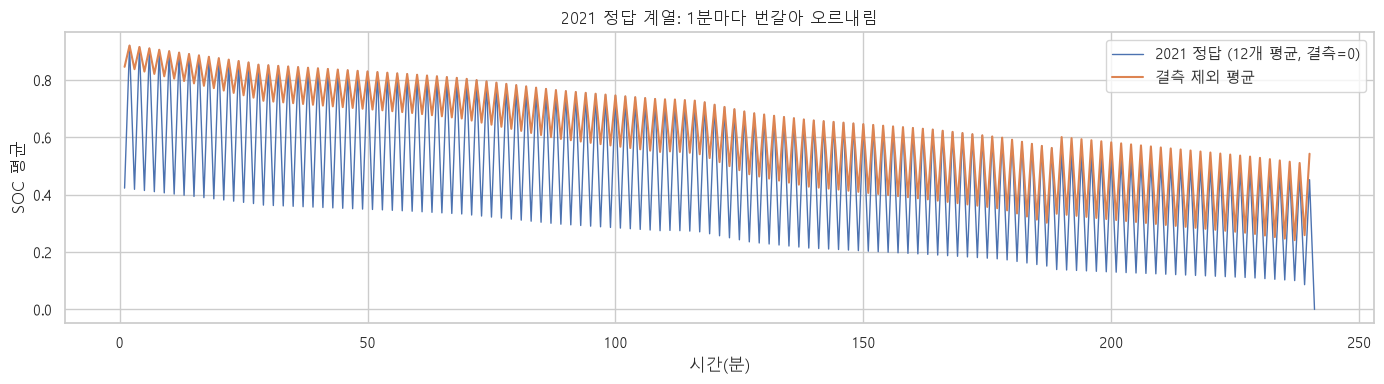

온도 정답 결측이 행마다 번갈아 나오나: True
정답 평균: 온도 정답 있음 0.6966 / 온도 정답 결측(0) 0.2493 (행 수 120 / 121)
2021 정답의 인접 행 차이 평균 절댓값 0.4470 vs 결측 제외 평균 nan


In [23]:
label = df_total[LST_COLS].shift(-1)
y_2021 = label.fillna(0).mean(axis=1)                        # 2021 정답 정의
temp_label_missing = label["25degc"].isna().astype(int)      # 다음 시점 온도값이 결측인 행 = 1

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_total["시간(분)"], y_2021, label="2021 정답 (12개 평균, 결측=0)", linewidth=1)
ax.plot(df_total["시간(분)"], label.mean(axis=1), label="결측 제외 평균", linewidth=1.5)
ax.set(xlabel="시간(분)", ylabel="SOC 평균", title="2021 정답 계열: 1분마다 번갈아 오르내림")
ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "Q2_2021_정답_패턴.png", dpi=150); plt.show()

grp = y_2021.groupby(temp_label_missing).agg(["count", "mean"]).rename(index={0: "온도 정답 있음", 1: "온도 정답 결측(0)"})
grp

# 정답의 모양: 온도 정답 결측 여부가 행마다 번갈아 바뀌는가, 그리고 평균이 얼마나 오르내리는가
flag = temp_label_missing.to_numpy()
alternates = bool((np.diff(flag) != 0).all())
print(f"온도 정답 결측이 행마다 번갈아 나오나: {alternates}")
print(f"정답 평균: {grp.index[0]} {grp['mean'].iloc[0]:.4f} / {grp.index[1]} {grp['mean'].iloc[1]:.4f} "
      f"(행 수 {int(grp['count'].iloc[0])} / {int(grp['count'].iloc[1])})")
print(f"2021 정답의 인접 행 차이 평균 절댓값 {np.abs(np.diff(y_2021.to_numpy())).mean():.4f} vs 결측 제외 평균 {np.abs(np.diff(label.mean(axis=1).to_numpy())).mean():.4f}")
RESULTS["Q2 온도 정답 결측 여부가 번갈아 바뀜"] = alternates

In [24]:
# 같은 8:2 분할(random_state=42)에서 입력 변수만 바꿔 R² 비교
idx_train, idx_test = train_test_split(np.arange(len(df_total)), test_size=0.2, random_state=42)
F = pd.DataFrame({"온도정답결측": temp_label_missing, "시간": df_total["시간(분)"]})

ablation = []
for feats in [["온도정답결측"], ["시간"], ["온도정답결측", "시간"]]:
    lr = LinearRegression().fit(F.iloc[idx_train][feats], y_2021.iloc[idx_train])
    ablation.append({"모델": "선형회귀", "입력": " + ".join(feats),
                     "test R2": r2_score(y_2021.iloc[idx_test], lr.predict(F.iloc[idx_test][feats]))})
ablation.append({"모델": "2021 RandomForest (seed 0~9 평균)", "입력": "12개 계열 현재값(결측=0)",
                 "test R2": rep.query("분할=='random'").R2.mean()})
ablation = pd.DataFrame(ablation)
ablation["test R2"] = ablation["test R2"].round(5)

r2_miss, r2_both = ablation["test R2"].iloc[0], ablation["test R2"].iloc[2]
RESULTS["Q2 결측여부 1개 변수 R2"] = r2_miss
RESULTS["Q2 결측여부+시간 선형회귀 R2"] = r2_both
ablation

,모델,입력,test R2
0,선형회귀,온도정답결측,0.75893
1,선형회귀,시간,0.21696
2,선형회귀,온도정답결측 + 시간,0.99209
3,2021 RandomForest (seed 0~9 평균),12개 계열 현재값(결측=0),0.99991


In [25]:
rf_mean = ablation["test R2"].iloc[3]
print(f"'다음 시점 온도값이 결측인가' 0/1 변수 하나 → R² {r2_miss:.3f}, + 시간(분) 선형회귀 → R² {r2_both:.3f}")
print(f"2021 RF(seed 10개 평균) R² {rf_mean:.5f} 대비 2변수 선형회귀 비율: {r2_both / rf_mean * 100:.1f}%")
print("→ 2021 R²의 대부분이 SOC 변화가 아니라 결측 패턴 + 시간 추세로 설명됨"
      if r2_both / rf_mean > 0.9 else "→ 2변수 선형회귀로는 RF R²의 90% 미만만 재현")

# 마지막 행: 다음 시점이 없어 12개 정답이 모두 결측 → 0 → MAPE·MPE 분모가 0
last_all_nan = bool(label.iloc[-1].isna().all())
zeros_in_v4 = int((v4["y_true"] == 0).sum())
m_v4 = metrics_2021(v4["y_true"], v4["y_pred"])
keep = v4["y_true"] != 0
m_v4_wo = metrics_2021(v4["y_true"][keep], v4["y_pred"][keep])
print(f"\n마지막 행({int(df_total['시간(분)'].iloc[-1])}분) 정답 12개 모두 결측: {last_all_nan} → 2021 코드에서 정답 0 처리")
print(f"v4 테스트셋(마지막 100행) 정답 0 개수: {zeros_in_v4}개 → MAPE {m_v4['MAPE']}, MPE {m_v4['MPE']}")
print(f"그 {zeros_in_v4}개 행만 빼면 MAPE {m_v4_wo['MAPE']:.2f}%, MPE {m_v4_wo['MPE']:.2f}%")
print(f"v4 테스트셋 정답(0 제외) 최솟값: {v4['y_true'][keep].min():.4f} → inf 원인은 낮은 SOC가 아니라 정답 0인 행")
RESULTS["Q2 v4 정답 0 개수"] = zeros_in_v4
RESULTS["Q2 v4 MAPE(정답 0 행 제외)"] = round(m_v4_wo["MAPE"], 2)
RESULTS["Q2 선형회귀2변수 / 2021 RF R2 비율(%)"] = round(r2_both / rf_mean * 100, 1)
DECISIONS.append({"단계": "Q2 원인 분해", "결정": "결측 여부·시간만 쓴 선형회귀와 2021 RF를 같은 분할에서 비교",
                  "이유": "R²가 무엇을 맞혔는지 변수 단위로 분리하기 위해", "근거": "Q2 제거 실험표"})

'다음 시점 온도값이 결측인가' 0/1 변수 하나 → R² 0.759, + 시간(분) 선형회귀 → R² 0.992
2021 RF(seed 10개 평균) R² 0.99991 대비 2변수 선형회귀 비율: 99.2%
→ 2021 R²의 대부분이 SOC 변화가 아니라 결측 패턴 + 시간 추세로 설명됨

마지막 행(241분) 정답 12개 모두 결측: True → 2021 코드에서 정답 0 처리
v4 테스트셋(마지막 100행) 정답 0 개수: 1개 → MAPE inf, MPE -inf
그 1개 행만 빼면 MAPE 33.65%, MPE -33.65%
v4 테스트셋 정답(0 제외) 최솟값: 0.0863 → inf 원인은 낮은 SOC가 아니라 정답 0인 행


**핵심 발견**
- 온도 정답 결측 여부가 매 행 번갈아 바뀜 → 정답 평균이 0.6966 ↔ 0.2493으로 한 행씩 오르내림
- '다음 시점 온도값이 결측인가' 0/1 변수 하나로 R² 0.759, 시간을 더한 선형회귀 2변수로 R² 0.992
- 즉 2021 R² 0.9999의 대부분은 SOC 변화가 아니라 결측 패턴과 시간 추세로 설명됨 (99.2%는 R² 비율이지 원인별 기여율이 아님)
- MAPE inf도 SOC가 낮아서가 아니라 마지막 행 정답이 0이 된 1개 행 때문. 그 행만 빼면 MAPE 33.65%

## Q3. 시간 순서를 지켜 검증하면
수업(260701)에서 배운 교차검증은 데이터를 섞어서 나눔. 시계열은 과거로 학습하고 미래로 평가해야 하므로 `TimeSeriesSplit` 사용.
같은 `TimeSeriesSplit(5)`를 정답 두 가지에 적용.
1. **2021 정답 그대로** (12개 평균, 결측=0)
2. **단일 계열 정답** (계열 하나의 다음 관측값, 온도 계열은 2분 뒤 값). 비교 기준으로 **지속 예측**(다음 값 = 현재 값) MAE도 같은 폴드에서 계산

In [26]:
X_2021 = df_total[LST_COLS].fillna(0)
tscv = TimeSeriesSplit(n_splits=5)
print("폴드 크기:", [(len(tr), len(te)) for tr, te in tscv.split(X_2021)])

rf_2021 = GridSearchCV(RandomForestRegressor(random_state=SEED),
                       {"bootstrap": [False], "n_estimators": [3, 5, 7, 9], "max_features": [2, 4, 6, 8]},
                       cv=3, n_jobs=-1, scoring="neg_mean_squared_error")

# (1) 2021 정답 그대로
fold_r2 = [r2_score(y_2021.iloc[te], clone(rf_2021).fit(X_2021.iloc[tr], y_2021.iloc[tr]).predict(X_2021.iloc[te]))
           for tr, te in tscv.split(X_2021)]
RESULTS["Q3 2021정답 TimeSeriesSplit R2 폴드별"] = [round(v, 3) for v in fold_r2]
print("(1) 2021 정답 + TimeSeriesSplit(5) 폴드별 R²:", np.round(fold_r2, 3), "평균", round(np.mean(fold_r2), 3))

폴드 크기: [(41, 40), (81, 40), (121, 40), (161, 40), (201, 40)]
(1) 2021 정답 + TimeSeriesSplit(5) 폴드별 R²: [0.987 0.976 0.949 0.939 0.963] 평균 0.963


In [27]:
# (2) 단일 계열 정답: 입력은 2021과 같은 12개 현재값(결측=0), 정답은 해당 계열의 다음 관측값
single = []
for col in LST_COLS:
    rows = df_total[col].notna()                                 # 이 계열이 관측된 행만 (온도는 홀수 분)
    yc = df_total.loc[rows, col].shift(-1).iloc[:-1]             # 같은 계열의 다음 관측값
    Xc, persist = X_2021[rows].iloc[:-1], df_total.loc[rows, col].iloc[:-1]
    for k, (tr, te) in enumerate(TimeSeriesSplit(n_splits=5).split(Xc)):
        pred = clone(rf_2021).fit(Xc.iloc[tr], yc.iloc[tr]).predict(Xc.iloc[te])
        single.append({"계열": col, "fold": k, "RF R2": r2_score(yc.iloc[te], pred),
                       "RF MAE(%p)": mean_absolute_error(yc.iloc[te], pred) * 100,
                       "지속예측 MAE(%p)": mean_absolute_error(yc.iloc[te], persist.iloc[te]) * 100})
single = pd.DataFrame(single)
single_summary = single.groupby("계열")[["RF R2", "RF MAE(%p)", "지속예측 MAE(%p)"]].mean().round(3)
RESULTS["Q3 단일계열 RF R2 평균(해안도로)"] = single_summary.loc["해안도로(70)", "RF R2"]
RESULTS["Q3 단일계열 중 RF가 지속예측보다 MAE가 큰 계열 수"] = int((single_summary["RF MAE(%p)"] > single_summary["지속예측 MAE(%p)"]).sum())
single_summary

,RF R2,RF MAE(%p),지속예측 MAE(%p)
계열,,,
-10degc,-4.027,3.284,0.289
-20degc,-3.860,4.136,0.374
0degc,-3.784,2.277,0.210
10degc,-4.026,2.099,0.189
1100고지(100),-3.525,6.730,0.463
25degc,-3.410,1.714,0.167
45degc,-3.817,1.953,0.184
bank1,-3.386,3.778,0.184
bank2,-3.573,5.236,0.250


In [28]:
n_worse = RESULTS["Q3 단일계열 중 RF가 지속예측보다 MAE가 큰 계열 수"]
r2_ser = single_summary["RF R2"]
print(f"(1) 2021 정답 그대로 시간순 검증: 폴드별 R² {np.round(fold_r2, 3)}, 평균 {np.mean(fold_r2):.3f}")
print(f"(2) 단일 계열 정답: 계열별 RF R² 최소 {r2_ser.min():.3f}({r2_ser.idxmin()}) ~ 최대 {r2_ser.max():.3f}({r2_ser.idxmax()})")
print(f"    RF MAE > 지속 예측 MAE인 계열: 12개 중 {n_worse}개")
print(f"→ 정답 정의만 바꿔도 R² {r2_ser.min():.3f} ~ {np.max(fold_r2):.3f}")
print("   → Q4부터는 계열 단위 정답 + 기준 모델(지속 예측)과 MAE 비교")
RESULTS["Q3 단일계열 RF R2 최소·최대"] = [round(float(r2_ser.min()), 3), round(float(r2_ser.max()), 3)]
RESULTS["Q3 2021정답 TimeSeriesSplit R2 평균"] = round(float(np.mean(fold_r2)), 3)
DECISIONS.append({"단계": "Q3 시간순 검증", "결정": "R² 대신 MAE + 기준 모델(지속 예측) 비교를 주 지표로 채택",
                  "이유": "같은 데이터에서 정답 정의에 따라 R² 값이 크게 달라지므로", "근거": "Q3 출력"})

(1) 2021 정답 그대로 시간순 검증: 폴드별 R² [0.987 0.976 0.949 0.939 0.963], 평균 0.963
(2) 단일 계열 정답: 계열별 RF R² 최소 -6.239(성판악(150)) ~ 최대 -3.386(bank1)
    RF MAE > 지속 예측 MAE인 계열: 12개 중 12개
→ 정답 정의만 바꿔도 R² -6.239 ~ 0.987
   → Q4부터는 계열 단위 정답 + 기준 모델(지속 예측)과 MAE 비교


**메모** 가설대로 2021 정답 그대로면 시간순 검증에서도 평균 R² 0.963.
정답을 계열 단위로 바꾸면 R² -6.239~-3.386, 12개 계열 모두 지속 예측보다 MAE가 큼 → R² 하나로는 판단 불가.
Q4부터는 계열 단위 정답 + 기준 모델과의 MAE 비교로 평가

## Q4. 문제 재정의 — 계열별 미래 SOC 예측

### 2021과 달라진 점

| 항목 | 2021 | 2026 재설계 | 근거 |
|---|---|---|---|
| 정답 | 12개 계열 다음 값의 평균(결측=0) | **각 계열의 H분 뒤 SOC** (H = 2, 10, 30, 60) | [설계 가정] 주행 가능 거리 안내에는 1분 뒤가 아니라 수십 분 뒤 값이 필요 |
| 결측 | 0으로 채움 | **채우지 않음**. 계열마다 실제 관측 시점만 사용 | Q2 |
| 모델 학습 대상 | SOC 수준(level) | **H분 동안의 평균 기울기(분당 변화율)** → 예측 SOC = 현재 SOC + 기울기×H | [가설] 트리 모델은 학습 범위 밖 수준을 외삽하지 못함 — 검증은 Q4의 M1/M2 비교 셀 |
| 분할 | 무작위 8:2 | **계열별 시간 기준 분할 + 퍼지(purge)**: 계열마다 자기 시간축의 마지막 20%를 평가 구간으로 두고, 학습 행은 `t + H ≤ 기준시각` 만 사용 | 학습 정답(t+H)이 평가 구간과 겹치는 누수 차단. 각 계열은 독립된 실험이고 t는 실험 시작 후 경과 분이므로, 전체 시각 하나로 자르면 평가에서 빠지는 계열이 생기는지는 Q4 분할 점검 셀에서 계산 |
| 튜닝 | GridSearchCV(cv=3, 섞인 폴드) | Pipeline + GridSearchCV, **학습 구간 내부의 시간 기준 폴드** | SeSAC 12-3 Pipeline 패턴 + FDS 프로젝트 검증 설계 |
| 비교 | RF 단일 | **기준 모델부터 한 단계씩**: 지속 → 직전 기울기 연장 → 3구간 평균 기울기 연장 → ML | FDS 프로젝트 정책 비교(P0→P6)의 단계 구조 |

In [29]:
# ── 긴 형태(long format)로 변환: 한 행 = (계열, 시각, SOC) ──
long = (pd.concat([df.melt(id_vars="t", var_name="계열", value_name="soc").assign(그룹=g) for g, df in raw.items()])
          .dropna(subset=["soc"]).sort_values(["계열", "t"], ignore_index=True))

by = long.groupby("계열")
long["rate"] = by["soc"].diff() / by["t"].diff()                          # 직전 구간 분당 기울기
long["rate_lag1"] = long.groupby("계열")["rate"].shift(1)                  # 그 이전 구간 기울기
long["rate_roll3"] = long.groupby("계열")["rate"].transform(lambda s: s.rolling(3).mean())  # 최근 3구간 평균 기울기

# 조건 변수(제거 실험용): 각 계열의 실험 조건 값. 해당 없는 그룹은 0, 그룹은 원-핫으로 구분
COND_VALUE = {"-20degc": -20, "-10degc": -10, "0degc": 0, "10degc": 10, "25degc": 25, "45degc": 45,
              "1100고지(100)": 1100, "성판악(150)": 780, "해안도로(70)": 70,      # 경로 최고 해발고도(m), 고도 논문 2.2절
              "bank1": 100, "bank2": 70, "bank3": 60}                              # SOH(%), 노후도 논문 표 5.1
long["온도_C"] = np.where(long["그룹"] == "온도", long["계열"].map(COND_VALUE), 0)
long["최고고도_m"] = np.where(long["그룹"] == "고도", long["계열"].map(COND_VALUE), 0)
long["SOH"] = np.where(long["그룹"] == "노후도", long["계열"].map(COND_VALUE), 0)
long = pd.concat([long, pd.get_dummies(long["그룹"], prefix="그룹", dtype=int)], axis=1)

BASE_FEATS = ["soc", "rate", "rate_lag1", "rate_roll3"]
COND_FEATS = ["온도_C", "최고고도_m", "SOH"] + [c for c in long.columns if c.startswith("그룹_")]
long.head()

,t,계열,soc,그룹,rate,rate_lag1,rate_roll3,온도_C,최고고도_m,SOH,그룹_고도,그룹_노후도,그룹_온도
0,1,-10degc,1.0000,온도,NaN,NaN,NaN,-10,0,0,0,0,1
1,3,-10degc,0.9976,온도,-0.0012,NaN,NaN,-10,0,0,0,0,1
2,5,-10degc,0.9952,온도,-0.0012,-0.0012,NaN,-10,0,0,0,0,1
3,7,-10degc,0.9928,온도,-0.0012,-0.0012,-0.0012,-10,0,0,0,0,1
4,9,-10degc,0.9904,온도,-0.0012,-0.0012,-0.0012,-10,0,0,0,0,1


In [30]:
H_LIST = [2, 10, 30, 60]          # 온도 계열이 2분 간격이므로 짝수 분만 사용
TEST_Q = 0.8                      # 계열마다 자기 시간축의 마지막 20%를 평가 구간으로
INNER_Q = [0.5, 0.625, 0.75, 0.875, 1.0]   # 학습 구간 내부 시간 폴드 경계(기준시각 대비 비율)

pipe = Pipeline([("pre", StandardScaler()), ("model", LinearRegression())])   # SeSAC 12-3: pre·model 두 자리
param_grid = [
    {"pre": [StandardScaler()], "model": [LinearRegression()]},
    {"pre": [StandardScaler()], "model": [Ridge()], "model__alpha": [0.1, 1, 10]},
    {"pre": [None], "model": [RandomForestRegressor(random_state=SEED, n_jobs=-1)],   # 트리: 스케일링 불필요
     "model__n_estimators": [200], "model__max_depth": [None, 6], "model__min_samples_leaf": [1, 5]},
]

ladder, store = [], {}
for H in H_LIST:
    # H분 뒤 SOC를 같은 계열에서 찾아 붙이기 (없으면 제외)
    fut = long[["계열", "t", "soc"]].rename(columns={"soc": "soc_future"}).assign(t=lambda d: d["t"] - H)
    d = long.merge(fut, on=["계열", "t"], how="inner").dropna(subset=BASE_FEATS).reset_index(drop=True)
    d["target_rate"] = (d["soc_future"] - d["soc"]) / H

    d["cut"] = d.groupby("계열")["t"].transform(lambda x: x.quantile(TEST_Q))   # 계열별 기준시각
    train = d[d["t"] + H <= d["cut"]].reset_index(drop=True)   # 퍼지: 학습 정답 시점(t+H)도 기준시각 이전
    test = d[d["t"] > d["cut"]].reset_index(drop=True)
    chk = train.groupby("계열")["t"].max().add(H).le(test.groupby("계열")["t"].min())
    assert chk.all() and set(train["계열"]) == set(test["계열"])

    # 학습 구간 내부 시간 기준 폴드 4개 (계열별 기준시각 대비 비율로 자르고, 각 폴드도 퍼지 적용)
    folds = [(np.where(train["t"] + H <= a * train["cut"])[0],
              np.where((train["t"] > a * train["cut"]) & (train["t"] <= b * train["cut"]))[0])
             for a, b in zip(INNER_Q[:-1], INNER_Q[1:])]

    grid = GridSearchCV(pipe, param_grid, cv=folds, scoring="neg_mean_absolute_error", n_jobs=-1)
    grid.fit(train[BASE_FEATS], train["target_rate"])

    preds = {
        "B0 지속 (변화 없음)": test["soc"],
        "B1 직전 기울기 연장": test["soc"] + test["rate"] * H,
        "B2 3구간 평균 기울기 연장": test["soc"] + test["rate_roll3"] * H,
        "M1 RF 수준 직접 예측 (2021 방식)": RandomForestRegressor(200, random_state=SEED, n_jobs=-1)
                                       .fit(train[BASE_FEATS], train["soc_future"]).predict(test[BASE_FEATS]),
        "M2 GridSearch 최적 (기울기 예측)": test["soc"] + grid.predict(test[BASE_FEATS]) * H,
    }
    mae_b0 = mean_absolute_error(test["soc_future"], preds["B0 지속 (변화 없음)"])
    for name, p in preds.items():
        mae = mean_absolute_error(test["soc_future"], p)
        ladder.append({"H(분)": H, "모델": name, "MAE(%p)": mae * 100, "R2": r2_score(test["soc_future"], p),
                       "지속 대비 MAE 감소율(%)": (1 - mae / mae_b0) * 100})
    store[H] = {"train": train, "test": test, "grid": grid, "preds": preds, "folds": folds}
    print(f"H={H:>2}분 | 학습 {len(train):>4}행 · 평가 {len(test):>3}행 · 평가 계열 {test['계열'].nunique()}개 | "
          f"GridSearchCV 최적: {grid.best_params_['model'].__class__.__name__}")

ladder = pd.DataFrame(ladder)
ladder.to_csv(OUT_DIR / "Q4_모델단계비교.csv", index=False, encoding="utf-8-sig")

H= 2분 | 학습 2490행 · 평가 629행 · 평가 계열 12개 | GridSearchCV 최적: LinearRegression
H=10분 | 학습 2359행 · 평가 616행 · 평가 계열 12개 | GridSearchCV 최적: RandomForestRegressor
H=30분 | 학습 2035행 · 평가 580행 · 평가 계열 12개 | GridSearchCV 최적: RandomForestRegressor
H=60분 | 학습 1549행 · 평가 526행 · 평가 계열 12개 | GridSearchCV 최적: LinearRegression


In [31]:
pd.options.display.float_format = "{:.4f}".format
ladder.pivot(index="모델", columns="H(분)", values="MAE(%p)")

H(분),2,10,30,60
모델,,,,
B0 지속 (변화 없음),0.3143,1.5628,5.1995,11.8686
B1 직전 기울기 연장,0.0271,0.3346,2.7509,6.3542
B2 3구간 평균 기울기 연장,0.0307,0.3702,2.7711,6.2185
M1 RF 수준 직접 예측 (2021 방식),0.3802,1.3323,3.6769,6.7009
M2 GridSearch 최적 (기울기 예측),0.0830,0.7054,1.7722,9.5337


In [32]:
ladder.pivot(index="모델", columns="H(분)", values="R2")

H(분),2,10,30,60
모델,,,,
B0 지속 (변화 없음),0.9988,0.9722,0.7023,-0.3849
B1 직전 기울기 연장,0.9997,0.9792,0.4944,-0.3089
B2 3구간 평균 기울기 연장,0.9998,0.9791,0.5278,-0.1969
M1 RF 수준 직접 예측 (2021 방식),0.9982,0.9751,0.8027,0.2524
M2 GridSearch 최적 (기울기 예측),0.9998,0.9852,0.8991,0.0469


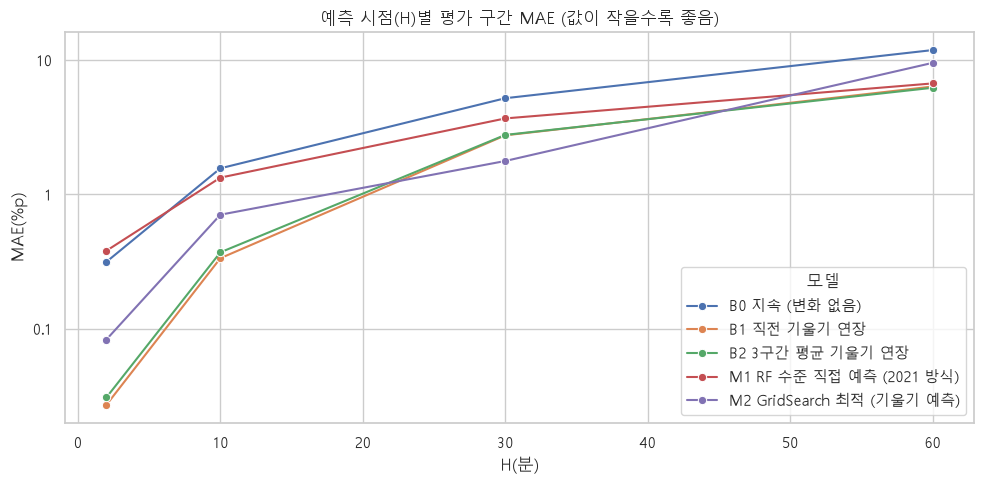

H= 2분: 최소 MAE = B1 직전 기울기 연장 (0.027%p) | 지속 R² 0.9988 | 2021 방식 RF MAE 0.380%p
H=10분: 최소 MAE = B1 직전 기울기 연장 (0.335%p) | 지속 R² 0.9722 | 2021 방식 RF MAE 1.332%p
H=30분: 최소 MAE = M2 GridSearch 최적 (기울기 예측) (1.772%p) | 지속 R² 0.7023 | 2021 방식 RF MAE 3.677%p
H=60분: 최소 MAE = B2 3구간 평균 기울기 연장 (6.218%p) | 지속 R² -0.3849 | 2021 방식 RF MAE 6.701%p

학습 없는 지속 예측도 H=2분 R² 0.9988 → 가까운 시점 R²는 모델 성능 근거가 안 됨


In [33]:
from matplotlib.ticker import FormatStrFormatter

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ladder, x="H(분)", y="MAE(%p)", hue="모델", marker="o", ax=ax)
ax.set(title="예측 시점(H)별 평가 구간 MAE (값이 작을수록 좋음)", yscale="log")
ax.yaxis.set_major_formatter(FormatStrFormatter("%g"))  # 로그축 눈금 0.1 형태로 (마이너스 기호 깨짐 방지)
plt.tight_layout(); plt.savefig(OUT_DIR / "Q4_H별_MAE.png", dpi=150); plt.show()

# 해석 문장도 결과값으로 바로 만듦 (숫자 옮겨 적다 틀리는 것 방지)
best_by_h = ladder.loc[ladder.groupby("H(분)")["MAE(%p)"].idxmin(), ["H(분)", "모델", "MAE(%p)"]]
RESULTS["Q4 H별 최소 MAE 모델"] = {int(r["H(분)"]): f'{r["모델"]} ({r["MAE(%p)"]:.3f}%p)' for _, r in best_by_h.iterrows()}
for H in H_LIST:
    sub = ladder[ladder["H(분)"] == H].set_index("모델")
    print(f"H={H:>2}분: 최소 MAE = {sub['MAE(%p)'].idxmin()} ({sub['MAE(%p)'].min():.3f}%p) | "
          f"지속 R² {sub.loc['B0 지속 (변화 없음)', 'R2']:.4f} | 2021 방식 RF MAE {sub.loc['M1 RF 수준 직접 예측 (2021 방식)', 'MAE(%p)']:.3f}%p")
r2_persist_h2 = ladder.query("`H(분)` == 2 and 모델 == 'B0 지속 (변화 없음)'")["R2"].item()
RESULTS["Q4 H=2 지속예측 R2"] = round(r2_persist_h2, 4)
print(f"\n학습 없는 지속 예측도 H=2분 R² {r2_persist_h2:.4f} → 가까운 시점 R²는 모델 성능 근거가 안 됨")

**메모** 아무것도 학습하지 않은 지속 예측도 2분 뒤 R² 0.9988 → 가까운 시점 R²가 높은 건 모델이 좋아서가 아님.
시점별 최소 MAE: 2분·10분은 직전 기울기 연장, 30분은 GridSearch 최적 모델(1.772%p), 60분은 3구간 평균 기울기 연장 → 4개 시점 중 3개에서 단순 계산이 머신러닝보다 정확

In [34]:
# ① 분할 설계 근거 점검: 전체 시각 하나로 자르면 평가에서 빠지는 계열이 있는가
tmax = long.groupby("계열")["t"].max()
global_cut = TEST_Q * tmax.max()
no_test = tmax[tmax <= global_cut].index.tolist()
print(f"계열별 마지막 관측 시각: 최소 {tmax.min():g}분({tmax.idxmin()}) ~ 최대 {tmax.max():g}분({tmax.idxmax()})")
print(f"전체 시각 {global_cut:g}분(최대 시각의 {TEST_Q:.0%})에서 자를 때 평가 행 없는 계열: {no_test}")
RESULTS["Q4 전체 시각 분할 시 평가 행 없는 계열"] = no_test

# ② 수준 직접 예측(M1)과 기울기 예측(M2·B1·B2)의 비교
mae_p = ladder.pivot(index="H(분)", columns="모델", values="MAE(%p)")
col = lambda prefix: next(c for c in mae_p.columns if c.startswith(prefix))
cmp_tab = pd.DataFrame({"M1 수준 RF": mae_p[col("M1")], "M2 기울기(GridSearch)": mae_p[col("M2")],
                        "B1 직전 기울기": mae_p[col("B1")], "B2 3구간 평균": mae_p[col("B2")], "B0 지속": mae_p[col("B0")]})
cmp_tab["최소 MAE 모델"] = cmp_tab.drop(columns=[]).idxmin(axis=1)
cmp_tab["M1 / M2 MAE 배율"] = cmp_tab["M1 수준 RF"] / cmp_tab["M2 기울기(GridSearch)"]
display(cmp_tab.round(4))
for H, r in cmp_tab.iterrows():
    print(f"H={H:>2}분: M1(수준 예측) MAE는 M2(기울기 예측)의 {r['M1 / M2 MAE 배율']:.2f}배, 최소 MAE 모델 = {r['최소 MAE 모델']}")
m1_better = [int(h) for h, v in cmp_tab["M1 / M2 MAE 배율"].items() if v < 1]
print(f"M1(수준 예측) MAE < M2(기울기 예측)인 H: {m1_better}")
RESULTS["Q4 M1이 M2보다 작은 H"] = m1_better
RESULTS["Q4 H별 M1/M2 MAE 배율"] = {int(h): round(float(v), 2) for h, v in cmp_tab["M1 / M2 MAE 배율"].items()}
RESULTS["Q4 H별 M1 MAE(%p)"] = {int(h): round(float(v), 3) for h, v in cmp_tab["M1 수준 RF"].items()}
RESULTS["Q4 H별 M2 MAE(%p)"] = {int(h): round(float(v), 3) for h, v in cmp_tab["M2 기울기(GridSearch)"].items()}
RESULTS["Q4 H별 B1 MAE(%p)"] = {int(h): round(float(v), 3) for h, v in cmp_tab["B1 직전 기울기"].items()}
RESULTS["Q4 H별 B2 MAE(%p)"] = {int(h): round(float(v), 3) for h, v in cmp_tab["B2 3구간 평균"].items()}

# ③ 단순 기울기 연장(B1·B2 중 작은 값)과 M2의 비교
base_best = cmp_tab[["B1 직전 기울기", "B2 3구간 평균"]].min(axis=1)
wins = (base_best <= cmp_tab["M2 기울기(GridSearch)"])
print(f"\n단순 기울기 연장(B1·B2 중 작은 값) MAE ≤ M2인 H: {[int(h) for h in wins[wins].index]} / 전체 {list(map(int, wins.index))}")
RESULTS["Q4 단순 기울기 연장이 M2 이하인 H"] = [int(h) for h in wins[wins].index]


계열별 마지막 관측 시각: 최소 189분(1100고지(100)) ~ 최대 585분(25degc)
전체 시각 468분(최대 시각의 80%)에서 자를 때 평가 행 없는 계열: ['-10degc', '-20degc', '1100고지(100)', 'bank1', 'bank2', 'bank3', '성판악(150)', '해안도로(70)']


,M1 수준 RF,M2 기울기(GridSearch),B1 직전 기울기,B2 3구간 평균,B0 지속,최소 MAE 모델,M1 / M2 MAE 배율
H(분),,,,,,,
2,0.3802,0.0830,0.0271,0.0307,0.3143,B1 직전 기울기,4.5820
10,1.3323,0.7054,0.3346,0.3702,1.5628,B1 직전 기울기,1.8886
30,3.6769,1.7722,2.7509,2.7711,5.1995,M2 기울기(GridSearch),2.0748
60,6.7009,9.5337,6.3542,6.2185,11.8686,B2 3구간 평균,0.7029


H= 2분: M1(수준 예측) MAE는 M2(기울기 예측)의 4.58배, 최소 MAE 모델 = B1 직전 기울기
H=10분: M1(수준 예측) MAE는 M2(기울기 예측)의 1.89배, 최소 MAE 모델 = B1 직전 기울기
H=30분: M1(수준 예측) MAE는 M2(기울기 예측)의 2.07배, 최소 MAE 모델 = M2 기울기(GridSearch)
H=60분: M1(수준 예측) MAE는 M2(기울기 예측)의 0.70배, 최소 MAE 모델 = B2 3구간 평균
M1(수준 예측) MAE < M2(기울기 예측)인 H: [60]

단순 기울기 연장(B1·B2 중 작은 값) MAE ≤ M2인 H: [2, 10, 60] / 전체 [2, 10, 30, 60]


**메모** 전체 시각 하나(468분)로 자르면 12개 중 8개 계열이 평가에서 빠짐 → 계열마다 자기 시간축의 마지막 20%로 자르는 설계가 필요했던 이유

In [35]:
# 최적 모델 + 시드 바꿔도 결과 같은지 (FDS 때 SHAP 시드 반복 점검한 방식)
H_MAIN = 30
s = store[H_MAIN]
print("H=30 GridSearchCV 최적 조합:", s["grid"].best_params_)
cv_table = (pd.DataFrame(s["grid"].cv_results_)
              .assign(모델=lambda d: d["param_model"].map(lambda m: m.__class__.__name__),
                      CV_MAE_pctp=lambda d: -d["mean_test_score"] * H_MAIN * 100)
              [["모델", "params", "CV_MAE_pctp", "rank_test_score"]].sort_values("rank_test_score"))
display(cv_table.head(8))

# 최적 조합은 그대로 두고 RandomForest의 random_state만 바꿔 평가 MAE가 얼마나 흔들리는지 확인
best_model = s["grid"].best_estimator_.named_steps["model"]
if isinstance(best_model, RandomForestRegressor):
    seed_mae = []
    for seed in range(5):
        est = clone(s["grid"].best_estimator_).set_params(model__random_state=seed)
        est.fit(s["train"][BASE_FEATS], s["train"]["target_rate"])
        seed_mae.append(mean_absolute_error(s["test"]["soc_future"], s["test"]["soc"] + est.predict(s["test"][BASE_FEATS]) * H_MAIN) * 100)
    RESULTS["Q4 H=30 최적 RF 시드5개 MAE(%p)"] = [round(v, 4) for v in seed_mae]
    print(f"최적 RF 조합, 시드 5개 평가 MAE: {np.round(seed_mae, 4)} → 최대-최소 {max(seed_mae) - min(seed_mae):.4f}%p")
else:
    print("최적 모델이 선형 → 난수 영향 없음")

H=30 GridSearchCV 최적 조합: {'model': RandomForestRegressor(n_jobs=-1, random_state=42), 'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 200, 'pre': None}


,모델,params,CV_MAE_pctp,rank_test_score
5,RandomForestRegressor,"{'model': RandomForestRegressor(n_jobs=-1, ran...",0.9011,1
7,RandomForestRegressor,"{'model': RandomForestRegressor(n_jobs=-1, ran...",0.9131,2
6,RandomForestRegressor,"{'model': RandomForestRegressor(n_jobs=-1, ran...",1.0052,3
4,RandomForestRegressor,"{'model': RandomForestRegressor(n_jobs=-1, ran...",1.0279,4
3,Ridge,"{'model': Ridge(), 'model__alpha': 10, 'pre': ...",2.1509,5
2,Ridge,"{'model': Ridge(), 'model__alpha': 1, 'pre': S...",2.1625,6
1,Ridge,"{'model': Ridge(), 'model__alpha': 0.1, 'pre':...",2.1637,7
0,LinearRegression,"{'model': LinearRegression(), 'pre': StandardS...",2.1638,8


최적 RF 조합, 시드 5개 평가 MAE: [1.8221 1.8007 1.8343 1.7786 1.8097] → 최대-최소 0.0558%p


In [36]:
# H=30 평가 구간을 그룹·계열별로 나눠 보기: 어느 데이터에서 오차가 나는가
s = store[H_MAIN]
by_series = []
for name, p in s["preds"].items():
    tmp = s["test"].assign(abs_err=np.abs(s["test"]["soc_future"] - np.asarray(p)) * 100)
    by_series.append(tmp.groupby(["그룹", "계열"])["abs_err"].mean().rename(name))
by_series = pd.concat(by_series, axis=1)
by_series.to_csv(OUT_DIR / "Q4_H30_계열별_MAE.csv", encoding="utf-8-sig")
display(by_series)

# 조건 변수(온도·고도·SOH·그룹) 넣으면 나아지나? 모델은 그대로, 입력만 바꿔 비교
cond_ablation = []
for H in H_LIST:
    s = store[H]
    for name, feats in [("기울기 이력만", BASE_FEATS), ("기울기 이력 + 조건 변수", BASE_FEATS + COND_FEATS)]:
        est = clone(s["grid"].best_estimator_).fit(s["train"][feats], s["train"]["target_rate"])
        pred = s["test"]["soc"] + est.predict(s["test"][feats]) * H
        cond_ablation.append({"H(분)": H, "입력": name, "MAE(%p)": mean_absolute_error(s["test"]["soc_future"], pred) * 100})
cond_ablation = pd.DataFrame(cond_ablation).pivot(index="입력", columns="H(분)", values="MAE(%p)")
RESULTS["Q4 조건변수 추가 시 MAE 변화(%p, H=30)"] = round(cond_ablation.loc["기울기 이력 + 조건 변수", 30] - cond_ablation.loc["기울기 이력만", 30], 4)
cond_ablation

B0 지속 (변화 없음)  B1 직전 기울기 연장  B2 3구간 평균 기울기 연장  \
그룹  계열                                                           
고도  1100고지(100)        10.3548       10.0645           10.6645   
    성판악(150)            8.3659       17.8049           17.8780   
    해안도로(70)            8.1323        2.8800            2.5846   
노후도 bank1               0.5933        2.5000            2.4000   
    bank2               1.6444        1.8000            1.9111   
    bank3               1.5844        2.4100            2.5711   
온도  -10degc             5.5810        0.0310            0.0310   
    -20degc             7.4882        0.0118            0.0118   
    0degc               6.3153        0.0153            0.0153   
    10degc              6.4652        0.0152            0.0152   
    25degc              4.8000        0.0000            0.0000   
    45degc              4.6649        0.0149            0.0149   

                 M1 RF 수준 직접 예측 (2021 방식)  M2 GridSearch 최적 (기울기 예측)  
그룹  계열                                                                
고도  1100고지(100)                    2.3329                     6.1644  
    성판악(150)                      10.9444                     6.5513  
    해안도로(70)                       3.3586                     2.5983  
노후도 bank1                          4.4442                     3.2135  
    bank2                          8.6313                     1.6158  
    bank3                          7.3422                     1.9518  
온도  -10degc                        1.1813                     0.0422  
    -20degc                        1.0247                     0.2410  
    0degc                          0.5840                     0.2135  
    10degc                         0.7037                     0.2412  
    25degc                         1.3294                     0.0066  
    45degc                         1.3073                     0.0208

H(분),2,10,30,60
입력,,,,
기울기 이력 + 조건 변수,0.0767,0.7535,1.8036,6.3085
기울기 이력만,0.0830,0.7054,1.7722,9.5337


In [37]:
b1c = [c for c in by_series.columns if c.startswith("B1")][0]
m2c = [c for c in by_series.columns if c.startswith("M2")][0]
b1_better = [s for _, s in by_series.index[by_series[b1c] < by_series[m2c]]]
m2_better = [s for _, s in by_series.index[by_series[m2c] < by_series[b1c]]]
print(f"H={H_MAIN} 계열별 MAE — B1이 M2보다 작은 계열 {len(b1_better)}개: {b1_better}")
print(f"H={H_MAIN} 계열별 MAE — M2가 B1보다 작은 계열 {len(m2_better)}개: {m2_better}")
RESULTS["Q4 H=30 B1이 M2보다 작은 계열"] = b1_better
RESULTS["Q4 H=30 M2가 B1보다 작은 계열"] = m2_better
by_series.round(4)

H=30 계열별 MAE — B1이 M2보다 작은 계열 7개: ['bank1', '-10degc', '-20degc', '0degc', '10degc', '25degc', '45degc']
H=30 계열별 MAE — M2가 B1보다 작은 계열 5개: ['1100고지(100)', '성판악(150)', '해안도로(70)', 'bank2', 'bank3']


B0 지속 (변화 없음)  B1 직전 기울기 연장  B2 3구간 평균 기울기 연장  \
그룹  계열                                                           
고도  1100고지(100)        10.3548       10.0645           10.6645   
    성판악(150)            8.3659       17.8049           17.8780   
    해안도로(70)            8.1323        2.8800            2.5846   
노후도 bank1               0.5933        2.5000            2.4000   
    bank2               1.6444        1.8000            1.9111   
    bank3               1.5844        2.4100            2.5711   
온도  -10degc             5.5810        0.0310            0.0310   
    -20degc             7.4882        0.0118            0.0118   
    0degc               6.3153        0.0153            0.0153   
    10degc              6.4652        0.0152            0.0152   
    25degc              4.8000        0.0000            0.0000   
    45degc              4.6649        0.0149            0.0149   

                 M1 RF 수준 직접 예측 (2021 방식)  M2 GridSearch 최적 (기울기 예측)  
그룹  계열                                                                
고도  1100고지(100)                    2.3329                     6.1644  
    성판악(150)                      10.9444                     6.5513  
    해안도로(70)                       3.3586                     2.5983  
노후도 bank1                          4.4442                     3.2135  
    bank2                          8.6313                     1.6158  
    bank3                          7.3422                     1.9518  
온도  -10degc                        1.1813                     0.0422  
    -20degc                        1.0247                     0.2410  
    0degc                          0.5840                     0.2135  
    10degc                         0.7037                     0.2412  
    25degc                         1.3294                     0.0066  
    45degc                         1.3073                     0.0208

**메모** 30분 뒤 기준 계열별로 나눠 보면 온도 6개와 bank1은 직전 기울기 연장이, 고도 3개와 bank2·3은 GridSearch 모델이 더 정확 → 어느 한 방식이 모든 계열에서 낫지는 않음

In [38]:
diff = cond_ablation.loc["기울기 이력 + 조건 변수"] - cond_ablation.loc["기울기 이력만"]
for H, v in diff.items():
    print(f"H={H:>2}분: 조건 변수 추가 시 MAE {v:+.4f}%p ({'감소' if v < 0 else '증가 또는 동일'})")
RESULTS["Q4 조건변수 추가 시 MAE 변화(%p, H별)"] = {int(h): round(float(v), 4) for h, v in diff.items()}
n_vals = long.groupby("계열")[["온도_C", "최고고도_m", "SOH"]].nunique().max().max()
print(f"\n계열 내 조건 변수 값 종류 수(최대): {int(n_vals)} → {'계열마다 상수 하나' if n_vals == 1 else '계열 안에서 값이 변함'}")
print(f"감소한 H: {[int(h) for h, v in diff.items() if v < 0]}, 증가한 H: {[int(h) for h, v in diff.items() if v >= 0]}")
print("[문서 인용] 세 그룹은 차량·장치가 다름(Q0 출처표) → 온도·고도·SOH 비교는 이 점 감안")
DECISIONS.append({"단계": "Q4 재설계", "결정": "정답=H분 뒤 SOC, 학습대상=평균 기울기, 시간기준 분할+퍼지, 기준 모델 단계 비교",
                  "이유": "Q2·Q3에서 2021 정답·분할·지표가 성능을 판단할 근거가 되지 못함을 확인", "근거": "Q4 단계 비교표"})

H= 2분: 조건 변수 추가 시 MAE -0.0063%p (감소)
H=10분: 조건 변수 추가 시 MAE +0.0481%p (증가 또는 동일)
H=30분: 조건 변수 추가 시 MAE +0.0314%p (증가 또는 동일)
H=60분: 조건 변수 추가 시 MAE -3.2252%p (감소)

계열 내 조건 변수 값 종류 수(최대): 1 → 계열마다 상수 하나
감소한 H: [2, 60], 증가한 H: [10, 30]
[문서 인용] 세 그룹은 차량·장치가 다름(Q0 출처표) → 온도·고도·SOH 비교는 이 점 감안


**메모** 조건 변수(온도·고도·SOH) 추가 효과는 2분·60분에서는 MAE 감소, 10분·30분에서는 증가 → 일관성 없음. 계열 안에서 조건 값이 상수 하나뿐이라 계열 구분 이상의 정보를 주기 어려운 구조

## Q5. 오차는 어디서 생기나
데이터가 구간별 직선이므로 예측 구간 `(t, t+H]` 안에 **기울기 변경점**이 없으면 기울기 연장만으로 오차가 거의 0이 될 것.
평가 행을 '구간 안에 변경점 있음 / 없음'으로 나눠 MAE 비교.

In [39]:
# 계열별 기울기 변경 시각: 그 시각 이후 구간의 기울기가 이전과 다름
change_times = {}
for col, gdf in long.groupby("계열"):
    r = gdf["rate"].round(6).to_numpy()
    change_times[col] = gdf["t"].to_numpy()[1:][np.abs(np.diff(r)) > 1e-6]

s = store[H_MAIN]
test = s["test"].copy()
test["구간 내 변경점"] = [bool(((change_times[c] > t) & (change_times[c] <= t + H_MAIN)).any())
                         for c, t in zip(test["계열"], test["t"])]
err_rows = []
for name in ["B1 직전 기울기 연장", "B2 3구간 평균 기울기 연장", "M2 GridSearch 최적 (기울기 예측)"]:
    test["abs_err"] = np.abs(test["soc_future"] - np.asarray(s["preds"][name])) * 100
    for flag, sub in test.groupby("구간 내 변경점"):
        err_rows.append({"모델": name, "예측 구간 안 기울기 변경점": "있음" if flag else "없음",
                         "평가 행 수": len(sub), "MAE(%p)": sub["abs_err"].mean(), "전체 오차 중 비중(%)": sub["abs_err"].sum() / test["abs_err"].sum() * 100})
err_break = pd.DataFrame(err_rows)
share = err_break.query("모델 == 'B1 직전 기울기 연장' and `예측 구간 안 기울기 변경점` == '있음'")["전체 오차 중 비중(%)"].item()
RESULTS["Q5 H=30 직전기울기 오차 중 변경점 구간 비중(%)"] = round(share, 1)
err_break

,모델,예측 구간 안 기울기 변경점,평가 행 수,MAE(%p),전체 오차 중 비중(%)
0,B1 직전 기울기 연장,없음,420,0.0000,0.0000
1,B1 직전 기울기 연장,있음,160,9.9719,100.0000
2,B2 3구간 평균 기울기 연장,없음,420,0.2907,7.5970
3,B2 3구간 평균 기울기 연장,있음,160,9.2819,92.4030
4,M2 GridSearch 최적 (기울기 예측),없음,420,0.4042,16.5154
5,M2 GridSearch 최적 (기울기 예측),있음,160,5.3631,83.4846


In [40]:
n_break, n_all = int(test["구간 내 변경점"].sum()), len(test)
print(f"H=30 평가 행 {n_all}개 중 {n_break}개({n_break / n_all * 100:.1f}%)는 예측 구간 안에 기울기 변경점 있음")
for name, sub in err_break.query("`예측 구간 안 기울기 변경점` == '있음'").set_index("모델").iterrows():
    print(f"  {name}: 전체 절대오차의 {sub['전체 오차 중 비중(%)']:.1f}%가 변경점이 있는 행에서 발생")
nb_b1 = err_break.query("모델 == 'B1 직전 기울기 연장' and `예측 구간 안 기울기 변경점` == '없음'")["MAE(%p)"].item()
print(f"B1의 변경점 없는 행 MAE: {nb_b1:.6f}%p")
print("→ B1은 변경점 없는 구간에서 MAE ≈ 0" if nb_b1 < 1e-6 else f"→ B1도 변경점 없는 구간에서 MAE {nb_b1:.6f}%p 남음")
for name in ["B2 3구간 평균 기울기 연장", "M2 GridSearch 최적 (기울기 예측)"]:
    r = err_break.query("모델 == @name and `예측 구간 안 기울기 변경점` == '있음'")["전체 오차 중 비중(%)"].item()
    RESULTS[f"Q5 H=30 {name[:2]} 오차 중 변경점 구간 비중(%)"] = round(r, 1)
RESULTS["Q5 H=30 변경점 포함 평가 행 / 전체"] = [n_break, n_all]
RESULTS["Q5 H=30 변경점 포함 행 비율(%)"] = round(n_break / n_all * 100, 1)
print("\n[가설, 미검증] 오차를 줄이려면 기울기가 언제 바뀌는지 알려 주는 입력(경로 고도, 속도, 외기온 등)이 필요해 보임. 이 데이터엔 없음")

H=30 평가 행 580개 중 160개(27.6%)는 예측 구간 안에 기울기 변경점 있음
  B1 직전 기울기 연장: 전체 절대오차의 100.0%가 변경점이 있는 행에서 발생
  B2 3구간 평균 기울기 연장: 전체 절대오차의 92.4%가 변경점이 있는 행에서 발생
  M2 GridSearch 최적 (기울기 예측): 전체 절대오차의 83.5%가 변경점이 있는 행에서 발생
B1의 변경점 없는 행 MAE: 0.000000%p
→ B1은 변경점 없는 구간에서 MAE ≈ 0

[가설, 미검증] 오차를 줄이려면 기울기가 언제 바뀌는지 알려 주는 입력(경로 고도, 속도, 외기온 등)이 필요해 보임. 이 데이터엔 없음


**메모** 30분 뒤 평가 580행 중 160행(27.6%)에만 변경점이 있는데, 직전 기울기 연장 오차의 100%, GridSearch 모델 오차의 83.5%가 그 160행에서 발생.
→ 오차를 줄이려면 모델을 바꾸기보다 '기울기가 언제 바뀌는지' 알려 주는 입력(고도, 속도, 외기온 등)이 필요해 보임. 이 데이터엔 그런 입력이 없어서 검증은 못 함

## Q6. 주행거리 환산식 점검
### 6-1. SOC → 주행거리 환산표 (`주행거리.xlsx`)
셀 메모: 「공인전비 383km, 배터리용량 60kWh 기준 / 주행거리 = 공인전비/배터리용량 × SOC」
`383/60`은 kWh당 km(전비). 여기에 곱할 값은 SOC(%)가 아니라 **남은 에너지(kWh) = 60 × SOC/100**.

In [41]:
dist = pd.read_excel(DATA_DIR / "주행거리.xlsx")
km_per_kwh = 383 / 60
dist["2021식(383/60×SOC)"] = km_per_kwh * dist["SOC"]
dist["수정식(383/60×60×SOC/100)"] = km_per_kwh * 60 * dist["SOC"] / 100       # = 3.83 × SOC

assert np.allclose(dist["주행거리"], dist["2021식(383/60×SOC)"])                 # 파일 값 = 2021식
ratio = (dist["2021식(383/60×SOC)"] / dist["수정식(383/60×60×SOC/100)"]).unique()
assert np.allclose(ratio, 100 / 60)
RESULTS["Q6 SOC100% 주행거리 (2021식 / 수정식, km)"] = [round(dist["2021식(383/60×SOC)"].iloc[-1], 2), round(dist["수정식(383/60×60×SOC/100)"].iloc[-1], 2)]
print(f"SOC 100%: 2021식 {dist['2021식(383/60×SOC)'].iloc[-1]:.2f}km / 수정식 {dist['수정식(383/60×60×SOC/100)'].iloc[-1]:.2f}km "
      f"→ 2021 값은 모든 SOC에서 {ratio[0]:.4f}배(=100/60) 과대")
dist.tail(3)

SOC 100%: 2021식 638.33km / 수정식 383.00km → 2021 값은 모든 SOC에서 1.6667배(=100/60) 과대


,SOC,주행거리,"공인전비 383km, 배터리용량 60kwh기준",2021식(383/60×SOC),수정식(383/60×60×SOC/100)
97,98,625.5667,NaN,625.5667,375.3400
98,99,631.9500,NaN,631.9500,379.1700
99,100,638.3333,NaN,638.3333,383.0000


**메모** 2021 환산식은 SOC 100%에서 638.33km → 모든 SOC에서 1.6667배(=100/60) 과대. 분모를 100으로 고치면 383.0km

### 6-2. 도심·고속 배분식
2021 코드(In[84]~[87]): 예상 주행거리 D를 무작위로 a(도심)와 D−a(고속)로 나눈 뒤 `(0.55a + 0.45(D−a)) × 0.7` 계산.
같은 폴더의 근거 파일 `도심주행, 고속주행적용식.txt` 내용은 아래.

In [42]:
basis_txt = DATA_DIR.parent / "도심주행, 고속주행적용식.txt"
print(basis_txt.read_text(encoding="utf-8-sig").strip() if basis_txt.exists() else f"(파일 없음: {basis_txt})")

국내 전기자동차 주행거리 측정은 환경부가 제정한 기준에 따라 시험됩니다. 
시험모드는 도심모드와 고속모드 두가지에 대한 평가를 진행하며, 
도심 55%, 고속 45% 기준으로 반영이 됩니다. 

 

{0.55 × 도심주행모드(CVS-75모드) 주행거리 + 0.45 × 고속도로주행 모드(HWFET 모드) 주행거리} x 0.7

이 최종 주행거리가 됩니다.


In [43]:
# 2021 방식: 결과 = 0.7 × (0.55a + 0.45(D − a)) = 0.7 × (0.45D + 0.10a),  0 < a < D
D = 344.7                                   # 2021 v6 캡처 Out[83]의 예상주행거리(194분)
a = rng.uniform(0.01, D, 100_000)           # 2021 코드처럼 a를 (0.01, D)에서 무작위 추출
final = 0.7 * (0.55 * a + 0.45 * (D - a))
lo, hi = final.min() / D, final.max() / D
assert 0.315 - 1e-3 <= lo and hi <= 0.385 + 1e-3
RESULTS["Q6 2021 배분식 결과/D 범위"] = [round(lo, 4), round(hi, 4)]
cap_ratio = 126.74 / D
print(f"10만 번 추출 결과: 최종값/D = {lo:.4f} ~ {hi:.4f} (이론값 0.7×0.45 = {0.7 * 0.45:.3f} ~ 0.7×0.55 = {0.7 * 0.55:.3f})")
print(f"2021 캡처 값 126.74km / D = {cap_ratio:.4f} → 범위 {'안' if lo <= cap_ratio <= hi else '밖'}")
print("→ 2021 방식 최종 주행거리는 a와 상관없이 D의 31.5~38.5%, 위치는 난수가 결정")
print("[문서 대조] txt 식은 도심·고속 모드 각각의 전체 주행거리를 가중평균하는 형태. 거리 하나를 둘로 나누는 2021 방식과 적용 대상이 다르다는 건 txt를 읽고 판단한 것 (코드 계산 아님)")
DECISIONS.append({"단계": "Q6 환산식", "결정": "환산표 단위 수정(×60/100), 도심·고속 배분식은 재현만 하고 사용하지 않음",
                  "이유": "단위 비율 100/60 확인, 배분식 결과가 난수 a에 의해 결정됨을 확인", "근거": "Q6 출력"})

10만 번 추출 결과: 최종값/D = 0.3150 ~ 0.3850 (이론값 0.7×0.45 = 0.315 ~ 0.7×0.55 = 0.385)
2021 캡처 값 126.74km / D = 0.3677 → 범위 안
→ 2021 방식 최종 주행거리는 a와 상관없이 D의 31.5~38.5%, 위치는 난수가 결정
[문서 대조] txt 식은 도심·고속 모드 각각의 전체 주행거리를 가중평균하는 형태. 거리 하나를 둘로 나누는 2021 방식과 적용 대상이 다르다는 건 txt를 읽고 판단한 것 (코드 계산 아님)


### 6-3. 예측 오차를 km로 — 과대 추정(방전 위험) 기준
FDS 프로젝트에서 '사기를 놓치는 비용'과 '정상 거래를 막는 비용'을 다르게 본 것과 같은 관점.
주행 가능 거리는 실제보다 크게 안내하는 쪽(과대 추정)이 방전 위험 → 과대 추정만 따로 집계하고, 이를 막는 안전 여유(margin)를 정함.
- 환산은 수정식(SOC 1%p = 3.83km). 단, 차종 근거 없는 2021 가정값(383km, 60kWh)을 그대로 쓴 예시 계산
- 노후도 그룹(계통연계 ESS)은 차량 주행거리로 환산할 수 없어 제외
- 안전 여유는 학습 구간 마지막 시간 폴드의 과대 추정 오차 95% 분위수로 정하고, 평가 구간엔 적용만 함 (평가 구간으로 여유를 정하면 그것도 누수)

In [44]:
KM_PER_SOC = 383.0                          # SOC 1.0(100%) = 383km (수정식, 2021 가정값)
s = store[H_MAIN]
tr, te = s["train"], s["test"]

# H=30 단계 비교에서 MAE가 가장 작은 모델(기울기 연장 2종 + GridSearch 최적 중)로 환산
cand = ["B1 직전 기울기 연장", "B2 3구간 평균 기울기 연장", "M2 GridSearch 최적 (기울기 예측)"]
range_model = (ladder[(ladder["H(분)"] == H_MAIN) & ladder["모델"].isin(cand)]
               .sort_values("MAE(%p)")["모델"].iloc[0])

def predict_soc(name, df, est):
    if name.startswith("B1"):
        return df["soc"] + df["rate"] * H_MAIN
    if name.startswith("B2"):
        return df["soc"] + df["rate_roll3"] * H_MAIN
    return df["soc"] + est.predict(df[BASE_FEATS]) * H_MAIN

# 안전 여유 산정용 검증 폴드 = 학습 구간 내부의 마지막 시간 폴드 (퍼지 적용, 평가 구간과 겹치지 않음)
fit_idx, val_idx = s["folds"][-1]
est_val = clone(s["grid"].best_estimator_).fit(tr.iloc[fit_idx][BASE_FEATS], tr.iloc[fit_idx]["target_rate"])
val = tr.iloc[val_idx]
val = val[val["그룹"] != "노후도"]                      # ESS는 주행거리로 환산할 수 없으므로 제외
val_err_km = (predict_soc(range_model, val, est_val) - val["soc_future"]) * KM_PER_SOC
margin_km = float(np.quantile(np.clip(val_err_km, 0, None), 0.95))

ev = te[te["그룹"] != "노후도"].copy()
ev["err_km"] = (predict_soc(range_model, ev, s["grid"].best_estimator_) - ev["soc_future"]) * KM_PER_SOC  # 양수 = 과대 추정
OVER = 0.01                                          # 0.01km 초과를 과대 추정으로 집계 (부동소수 오차 제외)

range_summary = {
    "평가 행 수(전기차 계열)": len(ev),
    "MAE(km)": ev["err_km"].abs().mean(),
    "과대 추정 비율(%)": (ev["err_km"] > OVER).mean() * 100,
    "과대 추정 최대(km)": ev["err_km"].max(),
    "안전 여유(검증 폴드 과대추정 95% 분위수, km)": margin_km,
    "여유 적용 후 과대 추정 비율(%)": ((ev["err_km"] - margin_km) > OVER).mean() * 100,
    "여유 적용 후 과대 추정 최대(km)": (ev["err_km"] - margin_km).max(),
}
RESULTS["Q6 H=30 주행거리 환산 모델"] = range_model
RESULTS["Q6 H=30 주행거리 오차 요약"] = {k: round(v, 3) for k, v in range_summary.items()}
print("환산에 사용한 모델:", range_model)
pd.Series(range_summary).round(3).to_frame("값")

환산에 사용한 모델: M2 GridSearch 최적 (기울기 예측)


,값
평가 행 수(전기차 계열),418.0000
MAE(km),6.0630
과대 추정 비율(%),80.3830
과대 추정 최대(km),65.1650
"안전 여유(검증 폴드 과대추정 95% 분위수, km)",2.2810
여유 적용 후 과대 추정 비율(%),22.0100
여유 적용 후 과대 추정 최대(km),62.8840


In [45]:
rs = range_summary
print(f"과대 추정 비율 {rs['과대 추정 비율(%)']:.1f}% → 안전 여유 {rs['안전 여유(검증 폴드 과대추정 95% 분위수, km)']:.2f}km 적용 후 {rs['여유 적용 후 과대 추정 비율(%)']:.1f}%")
print(f"과대 추정 최대값 {rs['과대 추정 최대(km)']:.1f}km → 여유 적용 후 {rs['여유 적용 후 과대 추정 최대(km)']:.1f}km")
# 여유 적용 후에도 남는 과대 추정이 변경점 구간에 몰려 있는지 + 검증·평가 구간 변경점 비율 비교
in_break = lambda df: np.array([bool(((change_times[c] > t) & (change_times[c] <= t + H_MAIN)).any())
                                for c, t in zip(df["계열"], df["t"])])
ev["구간 내 변경점"] = in_break(ev)
big_over = ev[(ev["err_km"] - margin_km) > OVER]
share_big = big_over["구간 내 변경점"].mean() * 100
share_val, share_ev = in_break(val).mean() * 100, ev["구간 내 변경점"].mean() * 100
print(f"여유 적용 후에도 남는 과대 추정 {len(big_over)}행 중 기울기 변경점 구간: {share_big:.1f}%")
print(f"기울기 변경점 구간 비율 — 검증 폴드 {share_val:.1f}% / 평가 구간 {share_ev:.1f}%")
RESULTS["Q6 잔여 과대추정 행 수"] = len(big_over)
RESULTS["Q6 잔여 과대추정 중 변경점 구간 비율(%)"] = round(share_big, 1)
RESULTS["Q6 변경점 구간 비율 검증폴드 / 평가구간(%)"] = [round(share_val, 1), round(share_ev, 1)]
if abs(share_val - share_ev) > 5:
    print(f"→ 검증 폴드와 평가 구간의 변경점 비율이 {abs(share_val - share_ev):.1f}%p 차이 → 검증 폴드 기준 고정 여유로는 평가 구간에서 같은 보호 수준 안 나옴"
          f"(과대 추정 비율 {rs['여유 적용 후 과대 추정 비율(%)']:.1f}% 남음).")
else:
    print("→ 검증 폴드와 평가 구간 변경점 비율 차이 5%p 이내")

과대 추정 비율 80.4% → 안전 여유 2.28km 적용 후 22.0%
과대 추정 최대값 65.2km → 여유 적용 후 62.9km
여유 적용 후에도 남는 과대 추정 92행 중 기울기 변경점 구간: 85.9%
기울기 변경점 구간 비율 — 검증 폴드 3.6% / 평가 구간 20.3%
→ 검증 폴드와 평가 구간의 변경점 비율이 16.7%p 차이 → 검증 폴드 기준 고정 여유로는 평가 구간에서 같은 보호 수준 안 나옴(과대 추정 비율 22.0% 남음).


**메모** 안전 여유 2.28km로 과대 추정 비율은 80.4% → 22.0%로 줄었지만, 최대 과대 추정은 65.2km → 62.9km로 거의 그대로. 남은 과대 추정의 85.9%가 기울기 변경점 구간.
검증 폴드(변경점 3.6%)와 평가 구간(20.3%)의 조건이 달라서 고정 여유로는 같은 수준의 보호가 안 됨 → Q5와 같은 결론

## Q7. 2021년에 쓰지 않은 데이터
### 7-1. `주행 속도와 soc_하이브리드.xlsx`
**[문서 인용]** 관련논문 폴더의 「하이브리드차량의 구동모터 속도에 따른 SOC 특성 연구」(2019) Fig. 4: **0~240초** 구간 SOC(약 40~55%)를 구동모터 상한속도 조건(−10km/h, 기준, +10km/h)별로 보여 줌 (논문 그림을 읽은 내용).
아래 셀에서 xlsx 파일 자체의 길이·시작값·단위를 계산해 그림과 비교.

In [46]:
hyb = pd.read_excel(DATA_DIR / "주행 속도와 soc_하이브리드.xlsx").rename(columns={"시간(분)/soc량": "t"})
hyb_profile = []
for col in hyb.columns.drop("t"):
    slope = np.diff(hyb[col].to_numpy())
    hyb_profile.append({"컬럼": col, "시작(%)": hyb[col].iloc[0], "끝(%)": round(hyb[col].iloc[-1], 2),
                        "증가한 분 수": int((slope > 1e-9).sum()),
                        "기울기 변경점 수": int((np.abs(np.diff(np.round(slope, 6))) > 1e-6).sum())})
hyb_profile = pd.DataFrame(hyb_profile)
RESULTS["Q7 하이브리드 파일 고속 컬럼 증가 분 수"] = int(hyb_profile.set_index("컬럼").loc["고속 주행", "증가한 분 수"])
display(hyb_profile)

hv = hyb.drop(columns="t")
bev_max = max(raw[g].drop(columns="t").max().max() for g in raw)           # 다른 원본 3종의 SOC 최댓값
print(f"하이브리드 파일: 시간 {hyb['t'].min():g}~{hyb['t'].max():g}분, 컬럼 {list(hv.columns)}, 시작값 {sorted(set(hv.iloc[0]))}")
print(f"SOC 값 범위 {hv.min().min():g}~{hv.max().max():g} (다른 원본 3종의 SOC 최댓값 {bev_max:g}) → 단위가 {'다름(%)' if hv.max().max() > 1 else '같음(0~1)'}")
print(f"논문 Fig.4(문서 인용)는 0~240초 = 0~4분, 파일은 {hyb['t'].max():g}분 → 시간 범위 불일치: {hyb['t'].max() > 4}")
RESULTS["Q7 하이브리드 파일 시간 최대(분)"] = float(hyb["t"].max())
RESULTS["Q7 하이브리드 파일 시작값(%)"] = sorted(set(map(float, hv.iloc[0])))
RESULTS["Q7 하이브리드 파일 SOC 최댓값"] = float(hv.max().max())
print("[판단] 단위·시간 범위가 다른 원본과 안 맞고 출처 확인 불가 → BEV 모델에 결합 안 함 (HEV 표기는 파일명·컬럼 기준)")

,컬럼,시작(%),끝(%),증가한 분 수,기울기 변경점 수
0,저속주행,70.0000,68.8200,0,0
1,시내 주행,70.0000,69.9500,29,7
2,고속 주행,70.0000,73.0000,39,6


하이브리드 파일: 시간 1~60분, 컬럼 ['저속주행', '시내 주행', '고속 주행'], 시작값 [70.0]
SOC 값 범위 68.82~73 (다른 원본 3종의 SOC 최댓값 1) → 단위가 다름(%)
논문 Fig.4(문서 인용)는 0~240초 = 0~4분, 파일은 60분 → 시간 범위 불일치: True
[판단] 단위·시간 범위가 다른 원본과 안 맞고 출처 확인 불가 → BEV 모델에 결합 안 함 (HEV 표기는 파일명·컬럼 기준)


### 7-2. `배터리 고도-전압fig5.xlsx` — 같은 경로의 전압 데이터

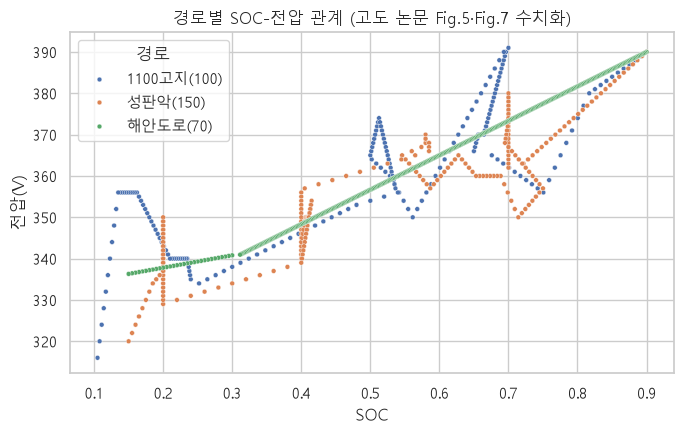

경로별 전압-SOC 상관계수:
 경로
1100고지(100)   0.8167
성판악(150)      0.8895
해안도로(70)      0.9965

경로 3개의 상관계수 범위: 0.8167 ~ 0.9965, 겹치는 (경로, 시각) 행 787개
전압·SOC는 같은 시각 값 → 상관이 높은 경로에선 전압을 넣어도 현재 SOC를 한 번 더 넣는 셈
[가설, 미검증] 1분 미만 해상도 전압·전류가 있으면 기울기 변경 시점 탐지(Q5)에 활용 가능성


In [47]:
volt = pd.read_excel(DATA_DIR / "배터리 고도-전압fig5.xlsx").rename(columns={"시간(분)": "t"})
soc_alt = raw["고도"]
pair = (volt.melt(id_vars="t", var_name="경로", value_name="전압(V)")
            .merge(soc_alt.melt(id_vars="t", var_name="경로", value_name="SOC"), on=["t", "경로"]).dropna())
corr_by_route = pair.groupby("경로")[["전압(V)", "SOC"]].corr().xs("SOC", level=1)["전압(V)"].round(4)
RESULTS["Q7 경로별 전압-SOC 상관"] = corr_by_route.to_dict()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=pair, x="SOC", y="전압(V)", hue="경로", s=12, ax=ax)
ax.set(title="경로별 SOC-전압 관계 (고도 논문 Fig.5·Fig.7 수치화)")
plt.tight_layout(); plt.savefig(OUT_DIR / "Q7_전압_SOC.png", dpi=150); plt.show()
print("경로별 전압-SOC 상관계수:\n", corr_by_route.to_string())
print(f"\n경로 {len(corr_by_route)}개의 상관계수 범위: {corr_by_route.min():.4f} ~ {corr_by_route.max():.4f}, 겹치는 (경로, 시각) 행 {len(pair)}개")
print("전압·SOC는 같은 시각 값 → 상관이 높은 경로에선 전압을 넣어도 현재 SOC를 한 번 더 넣는 셈")
print("[가설, 미검증] 1분 미만 해상도 전압·전류가 있으면 기울기 변경 시점 탐지(Q5)에 활용 가능성")

**메모** 전압-SOC 상관 0.817~0.997. 같은 시각 값이라 전압을 입력에 넣는 건 현재 SOC를 한 번 더 넣는 것과 비슷. 1분 미만 해상도 전압·전류가 있다면 기울기 변경 시점(Q5) 탐지에 써 볼 만함 (미검증)

## 분석기록표
무엇을 왜 바꿨는지 단계별 기록 (SeSAC 보고서 특강에서 배운 분석기록표 형식)

In [48]:
pd.set_option("display.max_colwidth", None)
pd.DataFrame(DECISIONS)

,단계,결정,이유,근거
0,Q1 재현,"컬럼 순서 sorted 고정, RF random_state를 10개 seed로 반복",2021 수치가 실행마다 달라진 원인을 분리하기 위해,Q1 재현표
1,Q2 원인 분해,결측 여부·시간만 쓴 선형회귀와 2021 RF를 같은 분할에서 비교,R²가 무엇을 맞혔는지 변수 단위로 분리하기 위해,Q2 제거 실험표
2,Q3 시간순 검증,R² 대신 MAE + 기준 모델(지속 예측) 비교를 주 지표로 채택,같은 데이터에서 정답 정의에 따라 R² 값이 크게 달라지므로,Q3 출력
3,Q4 재설계,"정답=H분 뒤 SOC, 학습대상=평균 기울기, 시간기준 분할+퍼지, 기준 모델 단계 비교",Q2·Q3에서 2021 정답·분할·지표가 성능을 판단할 근거가 되지 못함을 확인,Q4 단계 비교표
4,Q6 환산식,"환산표 단위 수정(×60/100), 도심·고속 배분식은 재현만 하고 사용하지 않음","단위 비율 100/60 확인, 배분식 결과가 난수 a에 의해 결정됨을 확인",Q6 출력


## 결과 요약 (코드로 생성)
아래 표는 앞 절의 변수와 `RESULTS`에서 코드가 만든 문장. 판정 기준도 같이 적었고, 계산값이 달라지면 판정도 같이 바뀜.
포트폴리오·면접 자료에 쓰는 숫자는 이 출력과 `outputs/`의 CSV, `results.json`에서만 가져옴.

In [49]:
# ── 가설 vs 결과표 (문장·판정 전부 변수에서 계산) ──
mp_ = ladder.pivot(index="H(분)", columns="모델", values="MAE(%p)")
pick = lambda p: next(c for c in mp_.columns if c.startswith(p))
b1_, b2_, m1_, m2_ = mp_[pick("B1")], mp_[pick("B2")], mp_[pick("M1")], mp_[pick("M2")]
best_ = mp_.idxmin(axis=1)
base_win = [int(h) for h in mp_.index if min(b1_[h], b2_[h]) <= m2_[h]]
cond_up = [int(h) for h, v in diff.items() if v >= 0]
cond_dn = [int(h) for h, v in diff.items() if v < 0]
b1_err = err_break.query("모델 == 'B1 직전 기울기 연장' and `예측 구간 안 기울기 변경점` == '있음'")["전체 오차 중 비중(%)"].item()
rf_mean_ = rep.query("분할 == 'random'").R2.mean()
inc_series = sorted(inc["계열"].unique())
ok_b = RESULTS["Q1b 2021 저장 R2"] is not None and RESULTS["Q1b 재현 R2 범위"][0] <= RESULTS["Q1b 2021 저장 R2"] <= RESULTS["Q1b 재현 R2 범위"][1]
m2_best_h = [int(h) for h in mp_.index if m2_[h] <= min(b1_[h], b2_[h])]

rows = [
    ["Q0", "논문 그래프를 수치화한 데이터이며 실측과 시뮬레이션이 섞여 있다",
     f"계열 {len(profile)}개, 계열당 기울기 변경점 최대 {profile['기울기 변경점 수'].max()}개, 직전과 같은 기울기 구간 비율 최소 {seg['직전과 같은 기울기 구간 비율(%)'].min():.1f}%, SOC 증가 구간이 있는 계열 {inc_series}",
     "구간별 직선 형태는 코드로 판정(같은 기울기 비율 ≥ 90%). 실측·시뮬레이션 구분은 문서 확인",
     "구간별 직선: 지지" if seg["직전과 같은 기울기 구간 비율(%)"].min() >= 90 else "구간별 직선: 불일치",],
    ["Q1", "동일 코드로 재현된다. MAPE·MPE는 실행마다 다르다",
     f"무작위 R² {r_rng[0]}~{r_rng[1]}, 마지막100행 R² {r_last[0]}~{r_last[1]}, 무작위 MAPE {mp[0]}~{mp[1]}, SOC예측코드 재현 R² {RESULTS['Q1b 재현 R2 범위']} (파일 저장값 {RESULTS['Q1b 2021 저장 R2']})",
     "2021 문서 R²가 seed 10개 재현 범위(소수 4자리) 안에 들면 재현",
     f"v4·v6 캡처: {'재현됨' if (ok_r and ok_l) else '일부 재현 안 됨'} / SOC예측코드 저장값: {'재현됨' if ok_b else '재현 안 됨(원인 미확인)'}"],
    ["Q2", "결측 0 처리로 생긴 규칙적 패턴을 맞힌 값이다",
     f"결측여부 1변수 선형회귀 R² {r2_miss:.3f}, +시간 R² {r2_both:.3f}, 2021 RF R² {rf_mean_:.5f} (비율 {r2_both / rf_mean_ * 100:.1f}%)",
     "선형회귀 2변수가 RF R²의 90% 이상 재현하면 지지",
     "지지" if r2_both / rf_mean_ > 0.9 else "불일치"],
    ["Q3", "시간순 검증에서도 R²가 높게 유지될 수 있고 R²만으로 판단할 수 없다",
     f"시간순 R² 폴드 {np.round(fold_r2, 3).tolist()}(평균 {np.mean(fold_r2):.3f}), 단일 계열 RF R² 최소 {r2_ser.min():.3f}, RF MAE > 지속예측 MAE인 계열 {n_worse}/12",
     "시간순 R² 평균 ≥ 0.9 이고 단일 계열 RF R² 최소 < 0 이면 지지",
     "지지" if (np.mean(fold_r2) >= 0.9 and r2_ser.min() < 0) else "불일치"],
    ["Q4", "단순 기울기 연장이 ML과 비슷하거나 더 낫다",
     "H별 최소 MAE 모델: " + ", ".join(f"H={int(h)} {best_[h].split()[0]}({mp_.loc[h].min():.3f}%p)" for h in mp_.index)
     + f" / B1·B2가 M2 이하인 H {base_win}, M2가 가장 작은 H {m2_best_h}",
     "B1·B2 중 작은 값 ≤ M2 인 H의 수",
     f"H {len(mp_)}개 중 {len(base_win)}개에서 지지 (지지 H: {base_win})"],
    ["Q5", "예측 구간 안 기울기 변경점이 있을 때 오차가 집중된다",
     f"H=30 평가 행의 {n_break / n_all * 100:.1f}%가 변경점 포함, B1 오차의 {b1_err:.1f}%가 그 행에서 발생",
     "B1 오차 중 변경점 구간 비중 > 변경점 행 비율",
     "지지" if b1_err > n_break / n_all * 100 else "불일치"],
    ["Q6", "환산표에 단위 오류가 있고 배분식은 난수가 결과 위치를 정한다",
     f"2021 값 / 수정식 = {ratio[0]:.4f}배(100/60 = {100 / 60:.4f}), 배분식 결과/D {lo:.3f}~{hi:.3f}, H=30 환산 MAE {range_summary['MAE(km)']:.3f}km",
     "비율이 100/60과 같고 결과/D가 이론 범위 안",
     "지지" if (np.isclose(ratio[0], 100 / 60) and 0.315 - 1e-3 <= lo and hi <= 0.385 + 1e-3) else "불일치"],
    ["Q7", "출처·단위가 달라 바로 결합할 수 없다",
     f"하이브리드 파일 SOC 최댓값 {hv.max().max():g}(다른 원본 최댓값 {bev_max:g}), 시간 최대 {hyb['t'].max():g}분, 전압-SOC 상관 {corr_by_route.min():.3f}~{corr_by_route.max():.3f}",
     "하이브리드 SOC 단위가 다른 원본과 다르면 지지",
     "지지(단위 불일치)" if hv.max().max() > 1 else "불일치"],
]
final_table = pd.DataFrame(rows, columns=["질문", "가설(검증 전)", "결과(코드 생성)", "판정 기준", "판정"])
final_table.to_csv(OUT_DIR / "최종_가설_결과표.csv", index=False, encoding="utf-8-sig")
pd.set_option("display.max_colwidth", None)
display(final_table)

,질문,가설(검증 전),결과(코드 생성),판정 기준,판정
0,Q0,논문 그래프를 수치화한 데이터이며 실측과 시뮬레이션이 섞여 있다,"계열 12개, 계열당 기울기 변경점 최대 18개, 직전과 같은 기울기 구간 비율 최소 92.4%, SOC 증가 구간이 있는 계열 ['1100고지(100)', 'bank1', '성판악(150)']",구간별 직선 형태는 코드로 판정(같은 기울기 비율 ≥ 90%). 실측·시뮬레이션 구분은 문서 확인,구간별 직선: 지지
1,Q1,동일 코드로 재현된다. MAPE·MPE는 실행마다 다르다,"무작위 R² 0.99967~0.99994, 마지막100행 R² 0.7903~0.7915, 무작위 MAPE 0.41~1.07, SOC예측코드 재현 R² [0.9997, 0.9998] (파일 저장값 0.9841)",2021 문서 R²가 seed 10개 재현 범위(소수 4자리) 안에 들면 재현,v4·v6 캡처: 재현됨 / SOC예측코드 저장값: 재현 안 됨(원인 미확인)
2,Q2,결측 0 처리로 생긴 규칙적 패턴을 맞힌 값이다,"결측여부 1변수 선형회귀 R² 0.759, +시간 R² 0.992, 2021 RF R² 0.99991 (비율 99.2%)",선형회귀 2변수가 RF R²의 90% 이상 재현하면 지지,지지
3,Q3,시간순 검증에서도 R²가 높게 유지될 수 있고 R²만으로 판단할 수 없다,"시간순 R² 폴드 [0.987, 0.976, 0.949, 0.939, 0.963](평균 0.963), 단일 계열 RF R² 최소 -6.239, RF MAE > 지속예측 MAE인 계열 12/12",시간순 R² 평균 ≥ 0.9 이고 단일 계열 RF R² 최소 < 0 이면 지지,지지
4,Q4,단순 기울기 연장이 ML과 비슷하거나 더 낫다,"H별 최소 MAE 모델: H=2 B1(0.027%p), H=10 B1(0.335%p), H=30 M2(1.772%p), H=60 B2(6.218%p) / B1·B2가 M2 이하인 H [2, 10, 60], M2가 가장 작은 H [30]",B1·B2 중 작은 값 ≤ M2 인 H의 수,"H 4개 중 3개에서 지지 (지지 H: [2, 10, 60])"
5,Q5,예측 구간 안 기울기 변경점이 있을 때 오차가 집중된다,"H=30 평가 행의 27.6%가 변경점 포함, B1 오차의 100.0%가 그 행에서 발생",B1 오차 중 변경점 구간 비중 > 변경점 행 비율,지지
6,Q6,환산표에 단위 오류가 있고 배분식은 난수가 결과 위치를 정한다,"2021 값 / 수정식 = 1.6667배(100/60 = 1.6667), 배분식 결과/D 0.315~0.385, H=30 환산 MAE 6.063km",비율이 100/60과 같고 결과/D가 이론 범위 안,지지
7,Q7,출처·단위가 달라 바로 결합할 수 없다,"하이브리드 파일 SOC 최댓값 73(다른 원본 최댓값 1), 시간 최대 60분, 전압-SOC 상관 0.817~0.997",하이브리드 SOC 단위가 다른 원본과 다르면 지지,지지(단위 불일치)


In [50]:
# ── 쓰면 안 되는 문장 + 근거 수치 ──
persist_h2 = ladder.query("`H(분)` == 2 and 모델 == 'B0 지속 (변화 없음)'")["R2"].item()
caution = pd.DataFrame([
    ["「R² 0.9999로 SOC를 정확히 예측」", f"결측여부+시간 선형회귀만으로 R² {r2_both:.3f}가 나옴 (Q2)"],
    ["「MAPE inf는 SOC가 낮은 구간 때문」", f"v4 테스트셋의 정답 0 행 {zeros_in_v4}개 때문이며, 그 행을 빼면 MAPE {m_v4_wo['MAPE']:.2f}% (Q2)"],
    ["「시간순으로 검증했으니 안전하다」", f"2021 정답 그대로 시간순 R² 평균 {np.mean(fold_r2):.3f}, 단일 계열 정답으로 바꾸면 RF R² 최소 {r2_ser.min():.3f} (Q3)"],
    ["「머신러닝이 단순 기울기 연장보다 우수」", f"B1·B2가 M2 이하인 H: {base_win}. H별 최소 MAE 모델: " + ", ".join(f"H={int(h)} {best_[h].split()[0]}" for h in mp_.index) + " (Q4)"],
    ["「가까운 시점 R²가 높으니 모델이 좋다」", f"학습 없는 지속 예측의 H=2 R² {persist_h2:.4f} (Q4)"],
    ["「2021 제출 코드(SOC예측코드.ipynb)의 R² 0.9841은 재현된다」", f"저장값 {RESULTS['Q1b 2021 저장 R2']} / 현재 폴더 데이터로 seed 10개 재현 {RESULTS['Q1b 재현 R2 범위']}: {'범위 안' if ok_b else '범위 밖'} (Q1-b)"],
    ["「수준을 직접 예측하는 2021 방식은 기울기 예측보다 항상 나쁘다」", f"H별 M1/M2 MAE 배율 {RESULTS['Q4 H별 M1/M2 MAE 배율']} (1 미만이면 M1이 더 좋음) (Q4)"],
    ["「조건 변수(온도·고도·SOH)를 넣으면 항상 좋아진다」", f"H별 MAE 변화 {RESULTS['Q4 조건변수 추가 시 MAE 변화(%p, H별)']} (Q4)"],
    ["「오차는 모델이 약해서 생긴다」", f"H=30 B1 오차의 {b1_err:.1f}%가 변경점 포함 행({n_break / n_all * 100:.1f}%)에서 발생 (Q5)"],
    ["「주행거리 383km는 그대로 사용 가능」", f"2021 환산표는 수정식의 {ratio[0]:.4f}배, 383km·60kWh는 차종 근거 없는 가정값 (Q6)"],
    ["「안전 여유를 두면 과대 추정이 사라진다」", f"여유 {range_summary['안전 여유(검증 폴드 과대추정 95% 분위수, km)']:.2f}km 적용 후에도 과대 추정 {range_summary['여유 적용 후 과대 추정 비율(%)']:.1f}% 남음 (Q6)"],
    ["「SOC 증가 구간은 회생제동의 결과」", f"증가 구간이 있는 계열 {inc_series}. 원인은 이 데이터로 확인하지 못함 (Q0, 원인은 문서 인용)"],
], columns=["피해야 할 문장", "근거(코드 출력)"])
caution.to_csv(OUT_DIR / "최종_주의문구표.csv", index=False, encoding="utf-8-sig")
display(caution)

,피해야 할 문장,근거(코드 출력)
0,「R² 0.9999로 SOC를 정확히 예측」,결측여부+시간 선형회귀만으로 R² 0.992가 나옴 (Q2)
1,「MAPE inf는 SOC가 낮은 구간 때문」,"v4 테스트셋의 정답 0 행 1개 때문이며, 그 행을 빼면 MAPE 33.65% (Q2)"
2,「시간순으로 검증했으니 안전하다」,"2021 정답 그대로 시간순 R² 평균 0.963, 단일 계열 정답으로 바꾸면 RF R² 최소 -6.239 (Q3)"
3,「머신러닝이 단순 기울기 연장보다 우수」,"B1·B2가 M2 이하인 H: [2, 10, 60]. H별 최소 MAE 모델: H=2 B1, H=10 B1, H=30 M2, H=60 B2 (Q4)"
4,「가까운 시점 R²가 높으니 모델이 좋다」,학습 없는 지속 예측의 H=2 R² 0.9988 (Q4)
5,「2021 제출 코드(SOC예측코드.ipynb)의 R² 0.9841은 재현된다」,"저장값 0.9841 / 현재 폴더 데이터로 seed 10개 재현 [0.9997, 0.9998]: 범위 밖 (Q1-b)"
6,「수준을 직접 예측하는 2021 방식은 기울기 예측보다 항상 나쁘다」,"H별 M1/M2 MAE 배율 {2: 4.58, 10: 1.89, 30: 2.07, 60: 0.7} (1 미만이면 M1이 더 좋음) (Q4)"
7,「조건 변수(온도·고도·SOH)를 넣으면 항상 좋아진다」,"H별 MAE 변화 {2: -0.0063, 10: 0.0481, 30: 0.0314, 60: -3.2252} (Q4)"
8,「오차는 모델이 약해서 생긴다」,H=30 B1 오차의 100.0%가 변경점 포함 행(27.6%)에서 발생 (Q5)
9,「주행거리 383km는 그대로 사용 가능」,"2021 환산표는 수정식의 1.6667배, 383km·60kWh는 차종 근거 없는 가정값 (Q6)"


In [51]:
# ── 한계 중 코드로 셀 수 있는 것 ──
n_per = long.groupby("계열")["t"].count()
s30 = store[H_MAIN]
print(f"계열 {long['계열'].nunique()}개, 계열당 관측 {n_per.min()}~{n_per.max()}행 (long 형식 기준)")
print(f"H={H_MAIN} 학습 {len(s30['train'])}행 / 평가 {len(s30['test'])}행, 평가 구간은 계열별 시간축의 마지막 {(1 - TEST_Q):.0%}")
print(f"평가 계열 수 {s30['test']['계열'].nunique()}개 (그룹별: {s30['test'].groupby('그룹')['계열'].nunique().to_dict()})")
print(f"주행거리 환산에서 제외한 그룹: {sorted(set(long['그룹']) - set(ev['그룹']))}")
RESULTS["한계 계열당 관측수 범위"] = [int(n_per.min()), int(n_per.max())]
RESULTS["한계 H=30 학습·평가 행 수"] = [len(s30["train"]), len(s30["test"])]

계열 12개, 계열당 관측 185~359행 (long 형식 기준)
H=30 학습 2035행 / 평가 580행, 평가 구간은 계열별 시간축의 마지막 20%
평가 계열 수 12개 (그룹별: {'고도': 3, '노후도': 3, '온도': 6})
주행거리 환산에서 제외한 그룹: ['노후도']


In [52]:
def to_jsonable(v):
    if isinstance(v, dict):
        return {str(k): to_jsonable(x) for k, x in v.items()}
    if isinstance(v, (list, tuple)):
        return [to_jsonable(x) for x in v]
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating, float)):
        return None if not np.isfinite(v) else float(v)
    return v

summary = to_jsonable(RESULTS)
(OUT_DIR / "results.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
for k, v in summary.items():
    print(f"- {k}: {v}")
print(f"\n저장: {OUT_DIR / 'results.json'}")

- 원본 xlsx 개수: 11
- 내용이 중복된 파일 쌍: 3
- 계열 수: 12
- 기울기 변경점 수 최대: 18
- 고도 데이터의 SOC 증가 구간 수: {'1100고지(100)': 57, '성판악(150)': 30, '해안도로(70)': 0}
- Q0 SOC 증가 구간 수(계열별): {'1100고지(100)': 57, 'bank1': 1, '성판악(150)': 30}
- Q0 데이터사전 파일 수: 11
- E2 분당 평균 하락률 최대 계열: 1100고지(100) (0.0042)
- E2 분당 평균 하락률 최소 계열: 25degc (0.0013)
- E4 직전과 같은 기울기 구간 비율 최소(%): 92.41
- E5 온도 결측이 짝수 분에만 있는가: True
- E5 12계열 모두 관측된 행 수: 95
- E6 수준 상관 최소·최대: [0.871, 1.0]
- E6 차분 상관 최소·최대: [-0.816, 0.344]
- E7 직선 적합 R² 최소·최대: [0.9491, 0.993]
- Q1 set(label_col)이 빼는 컬럼 수: [0]
- Q1 재현 R2 범위(무작위): [0.99967, 0.99994]
- Q1 재현 R2 범위(마지막100행): [0.7903, 0.7915]
- Q1 재현 MAPE 범위(무작위): [0.41, 1.07]
- 예측결과.xlsx 출처: df_total[:241] 자르기 없이 마지막 100행(260~359분)을 평가한 실행 (test_SOC 100행 일치)
- Q1 2021 R2 재현 여부(무작위, 마지막100행): [True, True]
- Q1b 재현 R2 범위: [0.9997, 0.9998]
- Q1b 2021 저장 R2: 0.9841
- Q1b 저장값이 재현 범위 안인 지표: ['MSE']
- Q2 온도 정답 결측 여부가 번갈아 바뀜: True
- Q2 결측여부 1개 변수 R2: 0.75893
- Q2 결측여부+시간 선형회귀 R2: 0.99209
- Q2 v4 정답 0 개수: 1
- Q2 v4 MAPE(정답 0 행 

## 한계
위 셀에서 계산한 항목(계열 수, 계열당 행 수, 학습·평가 행 수, 환산 제외 그룹) 말고, 코드로 확인하지 못한 한계는 **[문서 인용]** / **[미검증]** 으로 구분.
- **[문서 인용] 데이터 성격.** 모든 SOC 값은 논문 그래프를 수치화한 구간별 직선. 세 그룹은 차량·장치·실험 조건이 서로 다름 (출처표: 실측 BEV, 시뮬레이션 BEV, 시뮬레이션 ESS). 여기 수치는 '이 데이터에서 무엇이 성립하는가'일 뿐, 실제 차량 BMS의 SOC 예측 성능이 아님
- **[문서 인용] 주행거리 환산.** 383km·60kWh는 2021 환산표 셀 메모의 가정값이고 차종 근거 없음. 고도 데이터 차량(2017 쏘울 EV)의 배터리 공칭 에너지는 고도 논문 TABLE II 기준 30.5kWh
- **[미검증] 다음 단계에 필요한 데이터.** 1초~1분 해상도의 실제 주행 로그(속도, 전류, 전압, 외기온, 경로 고도)가 있으면 Q5에서 본 '기울기 변경 시점'을 입력 변수로 설명할 수 있는지 검증 가능. 이번엔 데이터가 없어서 못 함

## 회고
- 2021년엔 R² 0.9999를 그대로 결과로 씀. 다시 보니 그 숫자의 대부분은 결측 처리와 시간 추세에서 나온 것
- 점수가 높을수록 정답 정의, 결측 처리, 분할 방식부터 다시 볼 것
- R² 하나보다 지속 예측 같은 기준 모델과 비교하는 게 훨씬 많은 걸 알려 줌
- 원본 파일과 2021 결과를 assert로 대조해 두니, 재현이 맞는지 매번 확인할 수 있었음